Notes-
- Go through analysis procedures used for humans and check which apply to mice
- Check the new mouse data- mouse 28-30
- Force change and learning analysis parameters-
    - TTR
    - Range of applied force: expected to become more specified as the session progresses. 
    - Submovement analysis (force)- what parameters apply?
    - Force direction specificity/preference: does is change/is the learning easily changed for this? 
- What would trajectory changes look like in this case? 
- Touch-no touch epoch observation in mice data? 
- Saturation of data observed?  
- Pose tracking observations- labelling

Calculations for within trial variability-
- instaneous force magnitude
- change in instantaneous force magnitude- indvidually across one each vector, or cumulative across both vectors? 
- Instantaneous angular variability- across each vector or cumulative? 

INITIAL CHECKS

In [1]:
import datajoint as dj
dj.config.load('/home/coder/project/Secrets/dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment, behavior_analysis
import numpy as np


/home/coder/project/NDNF-pipeline/.venv/lib/python3.13/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-17 10:57:50,857][INFO]: DataJoint is configured from /home/coder/project/Secrets/dj_local_conf.json
[2026-09-17 10:57:50,880][INFO]: DataJoint 0.14.9 connected to rozmar@datajoint.ndnf.koki.hun-ren.hu:3306


In [ ]:
# ── Diagnostics: where does the M013 pipeline stop? ──────────────────────────
subject_id     = 'M029'
touch_param_id = 0
sat_param_id   = 0

n_force_traces = len(experiment.TrialForceTrace & {'subject_id': subject_id})
n_saturation   = len(behavior_analysis.TrialSaturationTimes
                      & {'subject_id': subject_id, 'sat_param_id': sat_param_id})
n_touch        = len(behavior_analysis.TrialTouchTimes
                      & {'subject_id': subject_id, 'touch_param_id': touch_param_id,
                         'sat_param_id': sat_param_id})
n_touch_epochs = len(behavior_analysis.TrialTouchTimes.TouchEpoch
                      & {'subject_id': subject_id, 'touch_param_id': touch_param_id,
                         'sat_param_id': sat_param_id})

print(f'{subject_id}:')
print(f'  TrialForceTrace rows:            {n_force_traces}')
print(f'  TrialSaturationTimes rows:       {n_saturation}  (sat_param_id={sat_param_id})')
print(f'  TrialTouchTimes rows:            {n_touch}  (touch_param_id={touch_param_id})')
print(f'  TrialTouchTimes.TouchEpoch rows: {n_touch_epochs}')

if n_force_traces == 0:
    print('\n-> No raw force traces ingested for this subject yet.')
elif n_saturation == 0:
    print('\n-> Raw traces exist, but TrialSaturationTimes has not been populated yet.')
elif n_touch == 0:
    print('\n-> TrialSaturationTimes is populated, but TrialTouchTimes has not been populated yet.')
else:
    print('\n-> Touch epochs exist — if the earlier cell was still empty, check its subject_id/touch_param_id match these.')

In [ ]:
# ── Populate TrialSubmovements for subm_param_id=2 (target-projected, amplitude-gated) ──
# NOTE: this writes new rows to the shared database. subm_param_id=2 is brand new and
# purely additive -- unlike re-populating an already-populated param id, no `.delete()`
# is needed first. Restrict to one subject first if you want to sanity-check a single
# mouse before running it for everyone, e.g.:
#   behavior_analysis.TrialSubmovements.populate(
#       {'subm_param_id': 2, 'subject_id': 'M036'}, display_progress=True, suppress_errors=True)
behavior_analysis.TrialSubmovements.populate(
    {'subm_param_id': 2}, display_progress=True, suppress_errors=True
)


In [ ]:
# ── Diagnostic: are subm_param_id 0/1/2 fully populated for every subject? ────
# Compares TrialSubmovements.key_source (every TrialTouchTimes x
# SubmovementDetectionParams combination that should exist) against what is
# already in TrialSubmovements, broken down by subject_id, for each
# subm_param_id. Read-only -- doesn't write anything. If any subm_param_id
# below shows missing subjects, run the populate cell that follows to backfill
# them (populate() is run unrestricted, across all subjects).
key_source = behavior_analysis.TrialSubmovements.key_source

any_missing = False
for subm_param_id in (0, 1, 2):
    source = key_source & {'subm_param_id': subm_param_id}
    missing = source - behavior_analysis.TrialSubmovements
    n_total, n_missing = len(source), len(missing)
    if n_missing == 0:
        print(f'subm_param_id={subm_param_id}: fully populated ({n_total} trial-rows)')
        continue

    any_missing = True
    missing_subjects = sorted({row['subject_id'] for row in missing.fetch('subject_id', as_dict=True)})
    print(f'subm_param_id={subm_param_id}: {n_missing}/{n_total} trial-rows NOT yet populated -- '
          f'{len(missing_subjects)} subject(s) affected: {missing_subjects}')

if any_missing:
    print('\n-> run the populate cell below to backfill the missing subm_param_id/subject combinations.')
else:
    print('\nAll subm_param_id 0/1/2 are fully populated for every subject -- no need to run the populate cell below.')


In [ ]:
# ── Populate TrialSubmovements for subm_param_id=0 and 1 (all subjects) ───────
# NOTE: this writes new rows to the shared database. populate() automatically
# skips keys that are already computed, so this is safe to re-run even when
# subm_param_id=0/1 are already fully or partially populated for some
# subjects -- only run this if the diagnostic cell above reported missing
# subjects for subm_param_id 0 or 1.
behavior_analysis.TrialSubmovements.populate(
    {'subm_param_id': 0}, display_progress=True, suppress_errors=True
)
#


In [ ]:
# ── Diagnostic: how populated is each submovement subm_param_id? ──────────────
# Row counts and block/subject coverage for subm_param_id=0/1/2 across the whole
# database -- run this any time to check progress (e.g. after the populate cell above,
# or before deciding what to restrict a populate call to).
for subm_param_id in (0, 1, 2):
    rows = behavior_analysis.TrialSubmovements() & {'subm_param_id': subm_param_id}
    n_rows = len(rows)
    if n_rows == 0:
        print(f'subm_param_id={subm_param_id}: not populated yet (0 rows)')
        continue

    # TrialSubmovements does not store `block` directly; join with the behavioral
    # trial table to recover the block number for each row.
    combos = (rows * experiment.BehaviorTrial()).fetch(
        'subject_id', 'session', 'block', as_dict=True
    )
    subjects = sorted({c['subject_id'] for c in combos})
    blocks = {(c['subject_id'], c['session'], c['block']) for c in combos}
    print(f'subm_param_id={subm_param_id}: {n_rows} trial-rows across '
          f'{len(blocks)} blocks, {len(subjects)} subjects: {subjects}')


In [ ]:
# ── Populate touch-epoch pipeline for M013 ────────────────────────────────
# NOTE: this writes new rows to the shared database. Run the diagnostics cell
# above first to confirm where the gap actually is.
subject_id = 'M029'

behavior_analysis.TrialSaturationTimes.populate(
    {'subject_id': subject_id}, display_progress=True, suppress_errors=True
)
behavior_analysis.TrialTouchTimes.populate(
    {'subject_id': subject_id}, display_progress=True, suppress_errors=True
)

In [ ]:
# ── Overview: sessions, blocks, and trials available for a subject ────────────
import numpy as np
import pandas as pd

subject_id = 'M029'

sessions = np.sort((experiment.Session & {'subject_id': subject_id}).fetch('session'))

if len(sessions) == 0:
    print(f'No sessions found for {subject_id}.')
else:
    rows = []
    for session in sessions:
        block_ids, feedback_types = (
            experiment.Block & {'subject_id': subject_id, 'session': int(session)}
        ).fetch('block', 'feedback_type', order_by='block')

        for block, feedback_type in zip(block_ids, feedback_types):
            trials = np.sort((experiment.BehaviorTrial
                               & {'subject_id': subject_id, 'session': int(session), 'block': int(block)}
                              ).fetch('trial'))
            rows.append({
                'session':       int(session),
                'block':         int(block),
                'feedback_type': feedback_type,
                'n_trials':      len(trials),
                'first_trial':   int(trials[0]) if len(trials) else None,
                'last_trial':    int(trials[-1]) if len(trials) else None,
                'trials':        trials.tolist(),
            })

    overview = pd.DataFrame(rows)
    print(f'{subject_id}: {overview["session"].nunique()} session(s), {len(overview)} block(s) total\n')
    print(overview.drop(columns='trials').to_string(index=False))
    # full per-trial numbers are still available in overview['trials'], e.g.:
    #   overview.loc[(overview.session == 8) & (overview.block == 0), 'trials'].iloc[0]

In [ ]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


In [ ]:

#subject_id = 'M004'#'mouse_bbenjamin'#'BCI81'
subject_id = 'mouse_judith'
#subject_id = 'mouse_bbenjamin'
subject_id = 'M013'

available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
trial_nums = []
hit_rates = []
session_lengths = []
for session in available_sessions:
    trials = (experiment.SessionTrial()&{'subject_id':subject_id,
                                         'session':session}).fetch('trial')
    trial_nums.append(len(trials))
    hits = len(experiment.BehaviorTrial()&{'subject_id':subject_id,'session':session,'outcome':'hit'})
    hit_rate = hits/len(trials) if len(trials)>0 else np.nan
    hit_rates.append(hit_rate)
    session_length = (experiment.SessionTrial()&{'subject_id':subject_id,'session':session,'trial':np.max(trials)}).fetch1('trial_end_time')
    session_lengths.append(session_length)
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax1.plot(available_sessions,trial_nums,'o-')
ax1.set_xlabel('session')
ax1.set_ylabel('number of trials')
plt.title(f'{subject_id} behavior overview')
ax2 = fig.add_subplot(3,1,2)
ax2.plot(available_sessions,session_lengths,'o-')
ax2.set_xlabel('session')
ax2.set_ylabel('session length (s)')
ax3 = fig.add_subplot(3,1,3)
ax3.plot(available_sessions,hit_rates,'o-')
ax3.set_xlabel('session')
ax3.set_ylabel('hit rate')
plt.tight_layout()
plt.show()

VISUALISATION PER MOUSE (OVERVIEW)

In [ ]:
# visualize targets, and how forces change over sessions and trials
import matplotlib.pyplot as plt

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'M029'  # subject to visualize
session        = [13]       # int for a single session; None = all sessions
blocks_to_show = [0]       # None = all blocks; or e.g. [0, 1, 4]

subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*20
epochs_to_include = ('quiescence', 'response', 'reward')  # same vocabulary as
                      # GUIs/behavior_gui.py's EpochSelector -- restricts the force
                      # histogram/distribution panels to samples within the selected
                      # trial epoch(s), e.g. ('response',)

def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))

def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    the same definition GUIs/behavior_gui.py's EpochSelector uses under the hood:
    quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing' (falls back
    to trial end); reward = 'reward' (falls back to 'threshold crossing') -> trial end. A
    trial missing the underlying event(s) simply has no entry for that epoch."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows

def _epoch_mask(times, window, epochs):
    """Boolean mask (same shape as `times`) -- True inside any requested epoch of
    `window` (one trial's dict from _epoch_windows_from_events)."""
    times = np.asarray(times, float)
    mask = np.zeros(times.shape, dtype=bool)
    for epoch in epochs:
        window_range = window.get(epoch)
        if window_range is None:
            continue
        lo, hi = window_range
        mask |= (times >= lo) & (times <= hi)
    return mask

if session is None:
    _sess = sorted(set(
        (experiment.Block() & {'subject_id': subject_id})
        .fetch('session').tolist()))
else:
    _sess = [session]

for session_i, session in enumerate(_sess):
    available_blocks,feedback_types = (experiment.Block()&{'subject_id':subject_id,'session':session}).fetch('block','feedback_type')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    
    for block,feedback_type in zip(available_blocks,feedback_types):
        if blocks_to_show is not None and int(block) not in blocks_to_show:
            continue
        task_setting_id,target_force_lut = (experiment.TaskSettings()*experiment.Block() &{'subject_id':subject_id,'session':session,'block':block}).fetch1('task_setting_id','target_force_lut')

        # epoch windows, fetched once per block
        _block_key = {'subject_id': subject_id, 'session': session, 'block': block}
        go_by_trial = _event_time_by_trial(_block_key, 'go')
        threshold_by_trial = _event_time_by_trial(_block_key, 'threshold crossing')
        reward_by_trial = _event_time_by_trial(_block_key, 'reward')
        trial_nums_all, trial_starts_all, trial_ends_all = (
            experiment.SessionTrial()*experiment.BehaviorTrial()*experiment.Block() & _block_key
        ).fetch('trial', 'trial_start_time', 'trial_end_time')
        epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                    trial_nums_all, trial_starts_all, trial_ends_all)
        
        fig = plt.figure(figsize=(8,8))
        ax_target_LUT = fig.add_subplot(2,2,1)
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                    'target_force_axes':fa['target_force_axes']}
        if force_uniform_range:
            im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
        im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                    force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                    origin='upper',
                                                    cmap='viridis',
                                                    aspect='auto')
        plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        plt.colorbar(im_lut,label='reward port speed')
        plt.title(f'{subject_id} s{session} b{block}: {feedback_type}')
        if force_uniform_range:
            ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
            ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])


        ax_performance = fig.add_subplot(2,2,3)
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','block':block}).fetch('trial','trial_event_time')    #break
        ax_performance.set_xlabel('trial#')
        ax_performance.plot(rewarded_trial,time_to_reward,'g.')
        if len(rewarded_trial)>10:
            ax_performance.plot(np.convolve(rewarded_trial,np.ones(10)/10,mode='valid'),
                                np.convolve(np.asarray(time_to_reward,float),np.ones(10)/10,mode='valid'),'g-')
        
        ax_performance.set_ylabel('time to get reward')
        
        ax_force_hist = fig.add_subplot(2,2,2)
        # fetch trial + time alongside each axis's values (rather than just the values)
        # so trials can be paired correctly between axes and restricted per-sample to
        # epochs_to_include below
        trials0_, times0_, vals0_ = (
            experiment.TrialForceTrace()*experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block()
            & {'subject_id':subject_id,'session':session,'force_axis_idx':0,'block':block}
        ).fetch('trial', 'force_trace_time', 'force_trace_value')
        trials1_, times1_, vals1_ = (
            experiment.TrialForceTrace()*experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block()
            & {'subject_id':subject_id,'session':session,'force_axis_idx':1,'block':block}
        ).fetch('trial', 'force_trace_time', 'force_trace_value')
        axis0_by_trial = {int(t): (tm, v) for t, tm, v in zip(trials0_, times0_, vals0_)}
        axis1_by_trial = {int(t): (tm, v) for t, tm, v in zip(trials1_, times1_, vals1_)}
        force_traces_0_, force_traces_1_ = [], []
        for _trial in sorted(set(axis0_by_trial) & set(axis1_by_trial)):
            _t_time, _v0 = axis0_by_trial[_trial]
            _, _v1 = axis1_by_trial[_trial]
            _mask = _epoch_mask(_t_time, epoch_windows.get(_trial, {}), epochs_to_include)
            if _mask.sum() == 0:
                continue
            force_traces_0_.append(np.asarray(_v0, dtype=float)[_mask])
            force_traces_1_.append(np.asarray(_v1, dtype=float)[_mask])
        if subtract_force_median:
            f0_baseline = np.median(np.concatenate(force_traces_0_))
            f1_baseline = np.median(np.concatenate(force_traces_1_))
            force_traces_0 = []
            for f in  force_traces_0_:
                force_traces_0.append(f-f0_baseline)
            force_traces_1 = []
            for f in  force_traces_1_:
                force_traces_1.append(f-f1_baseline)
        else:
            force_traces_0 = force_traces_0_
            force_traces_1 = force_traces_1_
        

        if force_uniform_range:
            histrange = [uniform_force_range[:2],uniform_force_range[:2]]
        else:
            histrange = [[force_axes_dict[0]['target_force_axes'][0],
                        force_axes_dict[0]['target_force_axes'][-1]],
                        [force_axes_dict[1]['target_force_axes'][0],
                        force_axes_dict[1]['target_force_axes'][-1]]]
        
        try:
            forcehist,binx,biny = np.histogram2d(np.concatenate(force_traces_0),
                                                np.concatenate(force_traces_1),
                                                range=histrange,
                                                bins=50)
            forcehist_all = forcehist.copy()
            forcehist = np.log(forcehist/sum(forcehist.flatten()))
            forcehist_ = forcehist.copy()
            forcehist_ [np.isinf(forcehist )] = 0
            forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
            im_hist = ax_force_hist.imshow(forcehist,
                                        extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                            alpha = 1)
            plt.colorbar(im_hist,label = 'fraction of time spent')
        except:
            pass

        _epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
        plt.title(f'Force distribution (epochs: {_epoch_label})')

        ax_force_hist_1d = fig.add_subplot(2,2,4)
        ax_force_hist_1d_2 = ax_force_hist_1d.twinx()
        try:
            ax_force_hist_1d.hist(np.concatenate(force_traces_0),binx,color = 'red',alpha = .5,label = 'force distribution ax 0')
            ax_force_hist_1d_2.hist(np.concatenate(force_traces_1),biny,color = 'blue',alpha = .5,label = 'force distribution ax 1')
            plt.legend()
            plt.xlabel('Force values')
        except:
            pass
        #ax_performance.set_yscale('log')
    

In [ ]:
# ── Per-trial TTR, force-magnitude change, and force-direction change ────────
# for specific sessions and blocks
import matplotlib.pyplot as plt
import pandas as pd

# ── parameters ───────────────────────────────────────────────────────────────
subject_id           = 'M029'
sessions_to_analyze  = [12,13,14,15,16,17,18]        # list of specific sessions, e.g. [8, 9]
blocks_to_analyze    = [0]     # list of specific blocks,  e.g. [0, 1]
epochs_to_include     = ('response', 'reward')  # same vocabulary as
                                  # GUIs/behavior_gui.py's EpochSelector -- subset to
                                  # restrict the magnitude/direction delta to a specific
                                  # trial epoch, e.g. ('response',) or ('reward',)

def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block that has this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    the same definition GUIs/behavior_gui.py's EpochSelector uses under the hood (via
    ndnf_pipeline/plot/behavior_plots.py's _epoch_windows_from_events): quiescence =
    trial start -> 'go' event; response = 'go' -> 'threshold crossing' (falls back to
    trial end if the trial has no threshold crossing, e.g. a miss); reward = 'reward'
    event (falls back to 'threshold crossing') -> trial end. A trial missing the
    event(s) an epoch depends on simply has no entry for that epoch. Returns
    {trial: {epoch_name: (start, end)}}."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows


def _epoch_mask(times, window, epochs):
    """Boolean mask (same shape as `times`) -- True where a sample falls inside any of
    the requested epochs of `window` (one trial's dict from _epoch_windows_from_events).
    A trial missing every requested epoch's underlying event ends up all-False."""
    times = np.asarray(times, float)
    mask = np.zeros(times.shape, dtype=bool)
    for epoch in epochs:
        window_range = window.get(epoch)
        if window_range is None:
            continue
        lo, hi = window_range
        mask |= (times >= lo) & (times <= hi)
    return mask


rows = []
for session in sessions_to_analyze:
    # blocks_to_analyze=None means "every block in this session" -- resolve it to the
    # actual blocks present rather than iterating over None directly
    if blocks_to_analyze is None:
        blocks_this_session = sorted((experiment.Block()
                                       & {'subject_id': subject_id, 'session': session}).fetch('block'))
    else:
        blocks_this_session = blocks_to_analyze
    for block in blocks_this_session:
        block_key = {'subject_id': subject_id, 'session': session, 'block': block}
        rewarded_trials, time_to_reward = (
            experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
            & {**block_key, 'trial_event_type': 'threshold crossing'}
        ).fetch('trial', 'trial_event_time', order_by='trial')

        # epoch windows, fetched once per block rather than per trial
        go_by_trial = _event_time_by_trial(block_key, 'go')
        threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
        reward_by_trial = _event_time_by_trial(block_key, 'reward')
        trial_nums, trial_starts, trial_ends = (
            experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
        ).fetch('trial', 'trial_start_time', 'trial_end_time')
        epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                    trial_nums, trial_starts, trial_ends)

        for trial, ttr in zip(rewarded_trials, time_to_reward):
            trial = int(trial)
            trace_key = {**block_key, 'trial': trial}

            ax_idx, times, ax_val = (
                experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
                & trace_key & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')
            if len(ax_val) < 2:
                continue
            f0 = ax_val[list(ax_idx).index(0)].astype(float)
            f1 = ax_val[list(ax_idx).index(1)].astype(float)
            t0 = times[list(ax_idx).index(0)].astype(float)
            if len(f0) < 2 or len(f1) < 2:
                continue

            # restrict to samples within the requested epoch(s); a trial with no samples
            # in that window (e.g. no 'reward' event, when only 'reward' is requested)
            # is skipped entirely
            mask = _epoch_mask(t0, epoch_windows.get(trial, {}), epochs_to_include)
            valid_idx = np.flatnonzero(mask)
            if len(valid_idx) < 2:
                continue
            first, last = valid_idx[0], valid_idx[-1]

            # instantaneous force magnitude and direction, cumulative across both vectors
            magnitude = np.sqrt(f0**2 + f1**2)
            direction = np.unwrap(np.arctan2(f1, f0))

            rows.append({
                'session':               session,
                'block':                 block,
                'trial':                 trial,
                'time_to_reward':        float(ttr),
                'delta_force_magnitude': float(magnitude[last] - magnitude[first]),
                'delta_force_direction': float(direction[last] - direction[first]),
            })

trial_metrics = pd.DataFrame(rows)
print(trial_metrics.to_string(index=False))

# ── plot per session/block ───────────────────────────────────────────────────
epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
for (session, block), df_sb in trial_metrics.groupby(['session', 'block']):
    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    axes[0].plot(df_sb['trial'], df_sb['time_to_reward'], 'g.-')
    axes[0].set_ylabel('time to reward (s)')
    axes[0].set_title(f'{subject_id}  session {session}  block {block}  (epochs: {epoch_label})')

    axes[1].plot(df_sb['trial'], df_sb['delta_force_magnitude'], '.-', color='tab:orange')
    axes[1].axhline(0, color='#999', lw=0.7, linestyle='--')
    axes[1].set_ylabel('Δ|F| per trial')

    axes[2].plot(df_sb['trial'], df_sb['delta_force_direction'], '.-', color='tab:blue')
    axes[2].axhline(0, color='#999', lw=0.7, linestyle='--')
    axes[2].set_ylabel('Δangle per trial (rad)')
    axes[2].set_xlabel('trial#')

    plt.tight_layout()
    plt.show()


In [ ]:
# ── Force-space trajectories per trial for specific subjects/sessions/blocks ──
# Traces are Gaussian-smoothed (sigma given in ms). Each panel shows the full
# target_force_lut as a background heatmap -- the exact target *region* (reward
# port speed as a function of force-axis-0/1 position) -- alongside the trial's
# start/end points.
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids          = ['M029']   # list of specific subjects
sessions_to_analyze  = [13]  # list of specific sessions
blocks_to_analyze    = [0]        # list of specific blocks
trials_to_show       = None     # None = every trial in the block; or e.g. [3, 4, 10, 11] to select specific trials
n_cols               = 5          # trajectories per row in the grid
gaussian_sigma_ms    = 3.0        # Gaussian smoothing width applied to each force trace (ms)
epochs_to_include    = ('response', 'reward')  # same vocabulary as
                                  # GUIs/behavior_gui.py's EpochSelector -- subset to
                                  # restrict each trajectory to a specific trial epoch,
                                  # e.g. ('response',) or ('reward',)

# high-contrast palette: dark trajectory over a light panel, saturated markers
TRAJ_COLOR   = '#0057b8'   # trajectory line
START_COLOR  = '#00c853'   # start of trial
END_COLOR    = '#ff1744'   # end of trial
PANEL_BG     = '#f2f2f2'   # fallback panel background when the LUT can't be fetched
LUT_CMAP     = 'viridis'   # target_force_lut background heatmap


if 'experiment' not in globals():
    print("`experiment` is not defined in this notebook; skipping trajectory plots. "
          "Run the cell that creates or imports the `experiment` schema first.")
else:
    def _lut_target_region(task_key):
        """(lut, fa0, fa1): the full target_force_lut -- a 2D array mapping
        force-axis-0/1 position to reward-port speed (mm/s), as stored for this
        task_setting_id -- together with its force-axis-0/1 coordinate vectors
        (target_force_axes). target_force_lut/task_setting_id is fixed per block,
        so this is the same region for every trial in that block."""
        lut = (experiment.TaskSettings() & task_key).fetch1('target_force_lut')
        ax_idx, ax_val = (experiment.TaskSettings.ForceAxis() & task_key).fetch(
            'force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
        fa = {int(i): np.asarray(v, dtype=float) for i, v in zip(ax_idx, ax_val)}
        return lut, fa[0], fa[1]


    def _gaussian_smooth(values, dt, sigma_ms):
        """Gaussian-smooth a 1D trace given its sample interval `dt` (s)."""
        if dt is None or dt <= 0 or len(values) < 2:
            return values
        sigma_samples = max((sigma_ms / 1000.0) / dt, 1e-6)
        return gaussian_filter1d(values, sigma=sigma_samples, mode='nearest')


    def _event_time_by_trial(key, event_type):
        """{trial: trial_event_time} for every trial in this block with this event type."""
        ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                              & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
        return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


    def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                    trial_nums, trial_starts, trial_ends):
        """Per-trial (quiescence, response, reward) time windows, relative to trial
        start -- the same definition GUIs/behavior_gui.py's EpochSelector uses under the
        hood: quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing'
        (falls back to trial end); reward = 'reward' (falls back to 'threshold
        crossing') -> trial end. A trial missing the underlying event(s) simply has no
        entry for that epoch. Returns {trial: {epoch_name: (start, end)}}."""
        windows = {}
        for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
            trial = int(trial)
            duration = end - start
            window = {}
            go_t = go_by_trial.get(trial)
            threshold_t = threshold_by_trial.get(trial)
            reward_t = reward_by_trial.get(trial)
            if go_t is not None:
                window['quiescence'] = (0.0, go_t)
                window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
            reward_start = reward_t if reward_t is not None else threshold_t
            if reward_start is not None:
                window['reward'] = (reward_start, duration)
            windows[trial] = window
        return windows


    def _epoch_mask(times, window, epochs):
        """Boolean mask (same shape as `times`) -- True where a sample falls inside any
        of the requested epochs of `window` (one trial's dict from
        _epoch_windows_from_events)."""
        times = np.asarray(times, float)
        mask = np.zeros(times.shape, dtype=bool)
        for epoch in epochs:
            window_range = window.get(epoch)
            if window_range is None:
                continue
            lo, hi = window_range
            mask |= (times >= lo) & (times <= hi)
        return mask


    for subject_id in subject_ids:
        for session in sessions_to_analyze:
            for block in blocks_to_analyze:
                trials = np.sort((
                    experiment.BehaviorTrial()
                    & {'subject_id': subject_id, 'session': session, 'block': block}
                ).fetch('trial'))
                if trials_to_show is not None:
                    trials = np.array([t for t in trials if int(t) in trials_to_show])
                if len(trials) == 0:
                    print(f'{subject_id} session {session} block {block}: no trials to show')
                    continue

                block_key = {'subject_id': subject_id, 'session': session, 'block': block}

                # epoch windows, fetched once per block rather than per trial
                go_by_trial = _event_time_by_trial(block_key, 'go')
                threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
                reward_by_trial = _event_time_by_trial(block_key, 'reward')
                trial_nums_all, trial_starts_all, trial_ends_all = (
                    experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
                ).fetch('trial', 'trial_start_time', 'trial_end_time')
                epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                            trial_nums_all, trial_starts_all, trial_ends_all)

                task_setting_id = (
                    experiment.TaskSettings() * experiment.Block()
                    & {'subject_id': subject_id, 'session': session, 'block': block}
                ).fetch1('task_setting_id')
                try:
                    lut, fa0, fa1 = _lut_target_region(
                        {'subject_id': subject_id, 'session': session, 'task_setting_id': task_setting_id})
                    # lut[i, j] <-> (fa0[i], fa1[j]); imshow wants array shape (ny, nx), so transpose
                    lut_disp = lut.T
                    lut_extent = [float(fa0.min()), float(fa0.max()), float(fa1.min()), float(fa1.max())]
                    lut_vmin, lut_vmax = float(np.nanmin(lut)), float(np.nanmax(lut))
                except Exception as e:
                    print(f'{subject_id} session {session} block {block}: could not fetch LUT target ({e})')
                    lut_disp = lut_extent = lut_vmin = lut_vmax = None

                n_rows = int(np.ceil(len(trials) / n_cols))
                fig, axes = plt.subplots(n_rows, n_cols,
                                          figsize=(4.2 * n_cols, 4.2 * n_rows),
                                          squeeze=False)
                fig.patch.set_facecolor('white')
                fig.subplots_adjust(hspace=0.6, wspace=0.5, top=0.9)
                epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
                fig.suptitle(f'{subject_id}  session {session}  block {block}  '
                             f'— force-space trajectory per trial (Gaussian σ={gaussian_sigma_ms:g} ms, '
                             f'epochs: {epoch_label})',
                             fontsize=13)

                lut_im = None
                for i, trial in enumerate(trials):
                    ax = axes[i // n_cols, i % n_cols]
                    trial = int(trial)
                    trace_key = {'subject_id': subject_id, 'session': session,
                                 'block': block, 'trial': trial}

                    if lut_disp is not None:
                        lut_im = ax.imshow(lut_disp, extent=lut_extent, origin='lower',
                                            cmap=LUT_CMAP, aspect='auto',
                                            vmin=lut_vmin, vmax=lut_vmax, zorder=0)
                    else:
                        ax.set_facecolor(PANEL_BG)

                    ax_idx, times, ax_val = (
                        experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
                        & trace_key & 'force_axis_idx < 2'
                    ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')

                    if len(ax_idx) < 2:
                        ax.set_visible(False)
                        continue

                    # Some trials may exist in the behavioral table but have no force samples
                    # for one or both axes; skip those panels rather than indexing empty arrays.
                    if any(len(np.asarray(v, dtype=float)) == 0 for v in ax_val[:len(ax_idx)]):
                        ax.set_visible(False)
                        continue

                    idx0 = list(ax_idx).index(0)
                    idx1 = list(ax_idx).index(1)
                    f0 = np.asarray(ax_val[idx0], dtype=float)
                    f1 = np.asarray(ax_val[idx1], dtype=float)
                    t0 = np.asarray(times[idx0], dtype=float)

                    if len(f0) == 0 or len(f1) == 0 or len(t0) == 0:
                        ax.set_visible(False)
                        continue

                    # restrict to samples within the requested epoch(s); a trial with no
                    # samples there (e.g. no 'reward' event, when only 'reward' is
                    # requested) is skipped entirely
                    epoch_ok = _epoch_mask(t0, epoch_windows.get(trial, {}), epochs_to_include)
                    f0, f1, t0 = f0[epoch_ok], f1[epoch_ok], t0[epoch_ok]
                    if len(f0) < 2:
                        ax.set_visible(False)
                        continue

                    dt = float(np.median(np.diff(t0))) if len(t0) > 1 else None

                    f0_smooth = _gaussian_smooth(f0, dt, gaussian_sigma_ms)
                    f1_smooth = _gaussian_smooth(f1, dt, gaussian_sigma_ms)

                    if len(f0_smooth) == 0 or len(f1_smooth) == 0:
                        ax.set_visible(False)
                        continue

                    ax.plot(f0_smooth, f1_smooth, '-', color=TRAJ_COLOR, lw=1.4, alpha=0.9, zorder=2)
                    ax.plot(f0_smooth[0], f1_smooth[0], 'o', color=START_COLOR, ms=8,
                            mec='black', mew=0.6, zorder=4, label='start')
                    ax.plot(f0_smooth[-1], f1_smooth[-1], 'o', color=END_COLOR, ms=8,
                            mec='black', mew=0.6, zorder=4, label='end')

                    if lut_extent is not None:
                        # re-center the view on the LUT (target region) midpoint: expand
                        # whichever side the trajectory pokes out of further, so the target
                        # heatmap always sits in the middle of the panel without ever
                        # cropping the trajectory.
                        cx = (lut_extent[0] + lut_extent[1]) / 2.0
                        cy = (lut_extent[2] + lut_extent[3]) / 2.0
                        xlim = ax.get_xlim()
                        ylim = ax.get_ylim()
                        half_x = max(cx - xlim[0], xlim[1] - cx)
                        half_y = max(cy - ylim[0], ylim[1] - cy)
                        ax.set_xlim(cx - half_x, cx + half_x)
                        ax.set_ylim(cy - half_y, cy + half_y)

                    ax.set_title(f'trial {trial}', fontsize=10)
                    ax.set_xlabel('force axis 0 (g)', fontsize=8)
                    ax.set_ylabel('force axis 1 (g)', fontsize=8)
                    ax.tick_params(labelsize=7)
                    ax.grid(True, color='white', alpha=0.3, linewidth=0.8, zorder=1)
                    for spine in ax.spines.values():
                        spine.set_color('#999999')

                # hide any unused grid cells
                for j in range(len(trials), n_rows * n_cols):
                    axes[j // n_cols, j % n_cols].set_visible(False)

                if lut_im is not None:
                    fig.colorbar(lut_im, ax=axes, shrink=0.5,
                                 label='target_force_lut: reward port speed (mm/s)')

                handles, labels = axes[0, 0].get_legend_handles_labels()
                if handles:
                    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
                               bbox_to_anchor=(0.5, -0.02))
                plt.show()


In [ ]:
# ── Curvature radius (R) and curvature (κ = 1/R) vs. time per trial ──────────
# Menger three-point curvature radius (same definition as menger_curvature_radius
# in behavior_analysis_Riddhi.ipynb and _menger_curvature_radius in the pipeline's
# TrialSubmovements), computed on the Gaussian-smoothed force-space trajectory.
# Both R and its inverse κ=1/R are plotted (R on top, log scale; κ below, linear),
# each post-smoothed with a median filter after the curvature calculation -- a
# median filter is used (rather than a mean/boxcar) because R has extreme outlier
# spikes (near-straight segments blow toward infinity) that a mean-based smoother
# would badly distort. One figure per (session, block).
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d, median_filter

# ── parameters ───────────────────────────────────────────────────────────────
subject_id            = 'M029'   # subject to inspect
sessions_to_analyze   = [12]      # list of sessions to view -- e.g. [4, 7, 8]
blocks_to_analyze     = [10]      # list of blocks to view -- e.g. [0, 1]
trials_to_show        = None     # None = every trial in the block; or e.g. [3, 4, 10, 11]
n_cols                = 5        # trials per row in the grid
gaussian_sigma_ms     = 30       # Gaussian smoothing width applied to each force trace (ms)
curvature_half_window = 5        # samples, half-window for the Menger radius (each side)
radius_floor_g        = 1e-3     # radius is clipped to at least this (g) before inverting,
                                  # so near-zero-area noise blips don't blow curvature up
post_smooth_window_ms = 50.0     # median-filter window applied to R and κ after computing them
time_range             = (0,5)    # None = whole trial; or (start_s, end_s), e.g. (5.0, 10.0),
                                  # to zoom both panels into a specific time-point range within
                                  # the trial. R and κ are still computed over the *whole* trace
                                  # first (so the Menger window/median filter keep seeing the
                                  # samples just outside the window) -- this only restricts what
                                  # gets displayed.
epochs_to_include      = ('response', 'reward')  # same vocabulary as
                                  # GUIs/behavior_gui.py's EpochSelector -- when this doesn't
                                  # cover the whole trial, each panel is additionally zoomed to
                                  # the selected epoch(s)' time range (intersected with
                                  # time_range above, if that's also set). Like time_range, this
                                  # only restricts the *display* -- R/κ are still computed over
                                  # the whole trace first.

RADIUS_COLOR = '#09363b'
CURV_COLOR   = '#8e1a1a'
PANEL_BG     = '#f2f2f2'


def _gaussian_smooth(values, dt, sigma_ms):
    """Gaussian-smooth a 1D trace given its sample interval `dt` (s)."""
    if dt is None or dt <= 0 or len(values) < 2:
        return values
    sigma_samples = max((sigma_ms / 1000.0) / dt, 1e-6)
    return gaussian_filter1d(values, sigma=sigma_samples, mode='nearest')


def _menger_curvature_radius(x, y, half_window=5):
    """Radius of curvature at each sample using the three-point Menger formula."""
    n = len(x)
    radius = np.full(n, np.inf)
    for i in range(half_window, n - half_window):
        x1, y1 = x[i - half_window], y[i - half_window]
        x2, y2 = x[i],               y[i]
        x3, y3 = x[i + half_window], y[i + half_window]
        a = np.hypot(x2 - x1, y2 - y1)
        b = np.hypot(x3 - x2, y3 - y2)
        c = np.hypot(x3 - x1, y3 - y1)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
        if area > 1e-12:
            radius[i] = (a * b * c) / (4 * area)
    return radius


def _median_smooth(values, dt, window_ms):
    """Median-filter a 1D trace given its sample interval `dt` (s); robust to outlier spikes."""
    if dt is None or dt <= 0 or len(values) < 2:
        return values
    size = max(1, int(round((window_ms / 1000.0) / dt)))
    if size % 2 == 0:
        size += 1
    return median_filter(values, size=size, mode='nearest')


def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    the same definition GUIs/behavior_gui.py's EpochSelector uses under the hood:
    quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing' (falls back
    to trial end); reward = 'reward' (falls back to 'threshold crossing') -> trial end. A
    trial missing the underlying event(s) simply has no entry for that epoch. Returns
    {trial: {epoch_name: (start, end)}}."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows


if 'experiment' not in globals():
    print("`experiment` is not defined in this notebook; skipping. "
          "Run the cell that creates or imports the `experiment` schema first.")
else:
    for session in sessions_to_analyze:
        for block in blocks_to_analyze:
            block_key = {'subject_id': subject_id, 'session': session, 'block': block}
            trials = np.sort((experiment.BehaviorTrial() & block_key).fetch('trial'))
            if trials_to_show is not None:
                trials = np.array([t for t in trials if int(t) in trials_to_show])
            if len(trials) == 0:
                print(f'{subject_id} session {session} block {block}: no trials to show')
                continue

            # epoch windows, fetched once per block rather than per trial
            go_by_trial = _event_time_by_trial(block_key, 'go')
            threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
            reward_by_trial = _event_time_by_trial(block_key, 'reward')
            trial_nums_all, trial_starts_all, trial_ends_all = (
                experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
            ).fetch('trial', 'trial_start_time', 'trial_end_time')
            epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                        trial_nums_all, trial_starts_all, trial_ends_all)

            # each trial gets a pair of stacked rows: radius R on top, curvature κ below
            n_row_pairs = int(np.ceil(len(trials) / n_cols))
            fig, axes = plt.subplots(n_row_pairs * 2, n_cols,
                                      figsize=(4.2 * n_cols, 3.2 * n_row_pairs * 2),
                                      squeeze=False)
            fig.patch.set_facecolor('white')
            fig.subplots_adjust(hspace=0.7, wspace=0.5, top=0.92)
            window_label = 'whole trial' if time_range is None else f'{time_range[0]:g}–{time_range[1]:g} s'
            epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
            fig.suptitle(f'{subject_id}  session {session}  block {block}  '
                         f'— curvature radius R (top) and κ=1/R (bottom) vs. time  '
                         f'(Menger half_window={curvature_half_window} samples, '
                         f'Gaussian σ={gaussian_sigma_ms:g} ms, '
                         f'post-smooth median window={post_smooth_window_ms:g} ms, '
                         f'window={window_label}, epochs={epoch_label})', fontsize=12)

            for i, trial in enumerate(trials):
                row_pair = i // n_cols
                col = i % n_cols
                ax_r = axes[2 * row_pair, col]        # curvature radius R
                ax_k = axes[2 * row_pair + 1, col]    # curvature kappa = 1/R
                ax_r.set_facecolor(PANEL_BG)
                ax_k.set_facecolor(PANEL_BG)
                trial = int(trial)
                trace_key = {**block_key, 'trial': trial}

                ax_idx, times, ax_val = (
                    experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
                    & trace_key & 'force_axis_idx < 2'
                ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')

                if len(ax_idx) < 2 or any(len(np.asarray(v, dtype=float)) == 0 for v in ax_val[:len(ax_idx)]):
                    ax_r.set_visible(False)
                    ax_k.set_visible(False)
                    continue

                idx0 = list(ax_idx).index(0)
                idx1 = list(ax_idx).index(1)
                f0 = np.asarray(ax_val[idx0], dtype=float)
                f1 = np.asarray(ax_val[idx1], dtype=float)
                t0 = np.asarray(times[idx0], dtype=float)
                if len(f0) == 0 or len(f1) == 0 or len(t0) == 0:
                    ax_r.set_visible(False)
                    ax_k.set_visible(False)
                    continue

                dt = float(np.median(np.diff(t0))) if len(t0) > 1 else None
                f0_smooth = _gaussian_smooth(f0, dt, gaussian_sigma_ms)
                f1_smooth = _gaussian_smooth(f1, dt, gaussian_sigma_ms)

                if len(f0_smooth) <= 2 * curvature_half_window:
                    ax_r.set_visible(False)
                    ax_k.set_visible(False)
                    continue

                curv_r = _menger_curvature_radius(f0_smooth, f1_smooth, half_window=curvature_half_window)
                # curvature = 1/radius; untouched boundary/degenerate samples (radius left at
                # its np.inf default) have zero curvature, and the radius is floored before
                # inverting so a near-zero-area noise blip doesn't blow curvature up
                curvature = np.where(np.isfinite(curv_r), 1.0 / np.clip(curv_r, radius_floor_g, None), 0.0)

                # post-smooth both, following the calculation above
                curv_r_smooth = _median_smooth(curv_r, dt, post_smooth_window_ms)
                curvature_smooth = _median_smooth(curvature, dt, post_smooth_window_ms)

                ax_r.plot(t0, curv_r_smooth, '-', color=RADIUS_COLOR, lw=1.1)
                ax_r.set_yscale('log')
                ax_r.set_title(f'trial {trial}', fontsize=10)
                ax_r.set_ylabel('radius R (g)', fontsize=8)
                ax_r.tick_params(labelsize=7)
                ax_r.grid(True, color='white', linewidth=0.8, zorder=0)
                for spine in ax_r.spines.values():
                    spine.set_color('#999999')

                ax_k.plot(t0, curvature_smooth, '-', color=CURV_COLOR, lw=1.1)
                ax_k.set_xlabel('time from trial start (s)', fontsize=8)
                ax_k.set_ylabel('curvature κ=1/R (1/g)', fontsize=8)
                ax_k.tick_params(labelsize=7)
                ax_k.grid(True, color='white', linewidth=0.8, zorder=0)
                for spine in ax_k.spines.values():
                    spine.set_color('#999999')

                # zoom to the selected epoch(s)' time range for this trial, intersected
                # with time_range above if that's also set; falls back to whatever
                # time_range alone gives if this trial is missing the epoch's event(s)
                display_range = time_range
                if epochs_to_include:
                    window = epoch_windows.get(trial, {})
                    epoch_bounds = [window[e] for e in epochs_to_include if e in window]
                    if epoch_bounds:
                        epoch_lo = min(b[0] for b in epoch_bounds)
                        epoch_hi = max(b[1] for b in epoch_bounds)
                        display_range = (max(display_range[0], epoch_lo), min(display_range[1], epoch_hi)) \
                            if display_range is not None else (epoch_lo, epoch_hi)

                if display_range is not None:
                    ax_r.set_xlim(display_range)
                    ax_k.set_xlim(display_range)

            # hide any unused grid cells (both rows of the pair)
            for j in range(len(trials), n_row_pairs * n_cols):
                rp, c = j // n_cols, j % n_cols
                axes[2 * rp, c].set_visible(False)
                axes[2 * rp + 1, c].set_visible(False)

            plt.show()


In [ ]:
# ── joint plot: target, force-space trajectory, and force dynamics per block ──
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter, butter, filtfilt

# ── parameters ───────────────────────────────────────────────────────────────
subject_id        = 'M029'       # subject to visualize
sessions_to_show  = [16,17]        # None = all sessions with blocks; int or list of ints to restrict
blocks_to_show    = [0]     # None = all blocks; int or list of ints to restrict
trials_to_show    = [0,1,2,3,4,5,6,7]          # None = every trial in the block; int or list of ints to restrict
time_range        = None       # None = each included trial's full duration; or (start, end) in
                                  # (s) from trial start -- same convention as force_trace_time --
                                  # to restrict every included trial to that time window
savgol_window_time = 0.03        # (s) approximate window length of the Savitzky-Golay filter applied
                                  # to each trial's force trace before computing dynamics
savgol_polyorder   = 3           # polynomial order fit within each window (must be < window length)
highpass_cutoff_hz = 1         # (Hz) Butterworth high-pass cutoff removing baseline drift/bias
                                  # from each trial's raw force trace, applied before Savitzky-Golay
                                  # smoothing
highpass_order     = 2           # Butterworth filter order (zero-phase via filtfilt)
align_event_type  = 'go'         # trial_event_type used as t=0 for the force speed/velocity
                                  # event-aligned average panels below
align_window      = (-1.0, 3.0)  # (s) window around the alignment event that the speed/velocity
                                  # mean +/- SEM panels are computed over
align_dt          = 0.01         # (s) common time-grid step that each trial's speed/velocity trace
                                  # is interpolated onto before averaging across trials
direction_n_bins  = 24           # number of angular bins for the force-direction rose plot

def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))

def _smooth_1d(x, dt):
    """Savitzky-Golay smoothing for a derived 1D signal, given its own sample interval
    `dt` (s) -- same filter/window convention as the per-trial f0/f1 smoothing below.
    Operates only on finite samples, so it stays safe for any measure that can contain
    non-finite sentinels."""
    finite = np.isfinite(x)
    n_finite = int(finite.sum())
    if n_finite < savgol_polyorder + 1:
        return x
    win = max(savgol_polyorder + 1, int(round(savgol_window_time / dt)))
    if win % 2 == 0:
        win += 1
    if win > n_finite:
        win = n_finite if n_finite % 2 == 1 else n_finite - 1
    if win <= savgol_polyorder:
        return x
    out = x.copy()
    out[finite] = savgol_filter(x[finite], window_length=win, polyorder=savgol_polyorder, mode='interp')
    return out

def _aligned_mean_sem(rows):
    """(mean, sem) across trials at each t_grid point, or (None, None) if `rows` is
    empty -- shared helper for every event-aligned panel below."""
    if not rows:
        return None, None
    matrix = np.vstack(rows)
    with np.errstate(invalid='ignore'):
        n = np.sum(~np.isnan(matrix), axis=0)
        mean = np.nanmean(matrix, axis=0)
        sem = np.nanstd(matrix, axis=0, ddof=1) / np.sqrt(np.maximum(n, 1))
    return mean, sem

t_grid = np.arange(align_window[0], align_window[1] + align_dt / 2, align_dt)

if sessions_to_show is None:
    _sessions = sorted(set(
        (experiment.Block() & {'subject_id': subject_id})
        .fetch('session').tolist()))
elif np.isscalar(sessions_to_show):
    _sessions = [sessions_to_show]
else:
    _sessions = list(sessions_to_show)

for session in _sessions:
    available_blocks, feedback_types = (experiment.Block() & {'subject_id': subject_id, 'session': session}).fetch('block', 'feedback_type')
    force_axes = (experiment.TaskSettings.ForceAxis() & {'subject_id': subject_id, 'session': session}).fetch(as_dict=True)

    for block, feedback_type in zip(available_blocks, feedback_types):
        if blocks_to_show is not None:
            _blocks = [blocks_to_show] if np.isscalar(blocks_to_show) else blocks_to_show
            if int(block) not in _blocks:
                continue

        task_setting_id, target_force_lut = (experiment.TaskSettings() * experiment.Block()
                                              & {'subject_id': subject_id, 'session': session, 'block': block}
                                              ).fetch1('task_setting_id', 'target_force_lut')
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {
                    'force_direction': fa['force_direction'],
                    'target_force_axes': fa['target_force_axes'],
                }

        # target position (LUT peak) -- for the target-projected velocity panel below
        peak_i, peak_j = np.unravel_index(np.nanargmax(target_force_lut), target_force_lut.shape)
        tgt_f0 = float(force_axes_dict[0]['target_force_axes'][peak_i])
        tgt_f1 = float(force_axes_dict[1]['target_force_axes'][peak_j])

        block_key = {'subject_id': subject_id, 'session': session, 'block': block}

        # concatenate force traces of every included trial in this block, in trial order --
        # each trial is high-pass filtered (baseline drift/bias removal) then Savitzky-Golay-
        # smoothed on its own full trace (so the fit near the edges of a later time_range crop
        # still has real data to work with), independently of every other trial, before any
        # time_range cropping or concatenation
        trials = sorted((experiment.BehaviorTrial() * experiment.Block()
                          & block_key).fetch('trial').tolist())
        if trials_to_show is not None:
            _trials = [trials_to_show] if np.isscalar(trials_to_show) else trials_to_show
            trials = [trial for trial in trials if trial in _trials]

        # time to reward per trial ('threshold crossing' event time from trial start,
        # same convention as the "Per-trial TTR" cell above), restricted to the same
        # `trials` selection as the force traces
        ttr_trial_all, ttr_value_all = (
            experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
            & {**block_key, 'trial_event_type': 'threshold crossing'}
        ).fetch('trial', 'trial_event_time', order_by='trial')
        ttr_mask = np.isin(ttr_trial_all, trials)
        ttr_trials_block = ttr_trial_all[ttr_mask]
        ttr_values_block = ttr_value_all[ttr_mask]

        # alignment event (t=0 for the speed/velocity mean +/- SEM panels below)
        align_by_trial = _event_time_by_trial(block_key, align_event_type)

        f0_list, f1_list, t_list = [], [], []
        speed_rows, vel0_rows, vel1_rows = [], [], []  # one row per trial, interpolated onto t_grid
        proj_rows, dtheta_rows = [], []                 # target-projected velocity, direction change
        theta_pool, weight_pool = [], []                # pooled per-sample direction/speed, all trials
        for trial in trials:
            trial_key = {'subject_id': subject_id, 'session': session, 'trial': trial}
            if len(experiment.TrialForceTrace() & trial_key) == 0:
                continue
            trace_time = (experiment.TrialForceTrace() & trial_key).fetch1('force_trace_time')
            axis_idx, axis_val = (experiment.TrialForceTrace.TrialForceAxis() & trial_key
                                  & 'force_axis_idx < 2').fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
            f_raw = {int(i): v for i, v in zip(axis_idx, axis_val)}
            if 0 not in f_raw or 1 not in f_raw or len(trace_time) < 3:
                continue

            trial_sample_interval = float(np.median(np.diff(trace_time)))
            win_samples = max(savgol_polyorder + 1, int(round(savgol_window_time / trial_sample_interval)))
            if win_samples % 2 == 0:
                win_samples += 1
            if win_samples > len(trace_time):
                win_samples = len(trace_time) if len(trace_time) % 2 == 1 else len(trace_time) - 1
            if win_samples <= savgol_polyorder:
                continue  # trial too short to fit the requested polyorder

            # remove baseline drift/bias before smoothing: zero-phase Butterworth high-pass,
            # per trial (same independence convention as the SG filtering below) -- skipped
            # if the trial is too short for filtfilt's default edge padding
            b_hp, a_hp = butter(highpass_order, highpass_cutoff_hz, btype='high', fs=1.0 / trial_sample_interval)
            hp_padlen = 3 * max(len(a_hp), len(b_hp))
            if len(trace_time) > hp_padlen:
                f0_hp = filtfilt(b_hp, a_hp, f_raw[0])
                f1_hp = filtfilt(b_hp, a_hp, f_raw[1])
            else:
                f0_hp, f1_hp = f_raw[0], f_raw[1]

            f0_smooth = savgol_filter(f0_hp, window_length=win_samples, polyorder=savgol_polyorder, mode='interp')
            f1_smooth = savgol_filter(f1_hp, window_length=win_samples, polyorder=savgol_polyorder, mode='interp')

            if time_range is not None:
                mask = (trace_time >= time_range[0]) & (trace_time <= time_range[1])
                trace_time = trace_time[mask]
                f0_smooth, f1_smooth = f0_smooth[mask], f1_smooth[mask]
                if len(trace_time) < 2:
                    continue

            # per-trial dynamics -- computed per trial (not on the block-concatenated trace
            # below) so a trial boundary never shows up as a spurious speed/direction spike
            df0_t, df1_t = np.diff(f0_smooth), np.diff(f1_smooth)
            if len(df0_t) >= 2:
                t_dyn = trace_time[1:]
                speed_t = _smooth_1d(np.sqrt(df0_t**2 + df1_t**2) / trial_sample_interval, trial_sample_interval)
                vel0_t = _smooth_1d(df0_t / trial_sample_interval, trial_sample_interval)
                vel1_t = _smooth_1d(df1_t / trial_sample_interval, trial_sample_interval)
                theta_t = np.arctan2(df1_t, df0_t)

                # target-projected velocity: vel0_t/vel1_t projected onto the direction from
                # the (smoothed) force position to the block's target -- same construction as
                # behavior_analysis._boundaries_target_projected_zero_crossing (subm_param_id=1),
                # but on the already-smoothed velocity rather than raw, for a cleaner signal.
                # Positive = net progress toward the target; negative = moving away from it.
                dx_t = tgt_f0 - f0_smooth[:-1]
                dy_t = tgt_f1 - f1_smooth[:-1]
                dist_t = np.clip(np.hypot(dx_t, dy_t), 1e-9, None)
                ux_t, uy_t = dx_t / dist_t, dy_t / dist_t
                proj_t = vel0_t * ux_t + vel1_t * uy_t

                # change in force direction (rad/s): angular velocity of the (unwrapped)
                # force-velocity heading -- same measure as the rose plot's per-sample theta,
                # but its rate of change over time instead of its pooled distribution
                dtheta_t = None
                if len(theta_t) >= 3:
                    theta_unwrapped_t = np.unwrap(theta_t)
                    dtheta_t = _smooth_1d(np.diff(theta_unwrapped_t) / trial_sample_interval, trial_sample_interval)
                    t_dtheta = t_dyn[1:]

                # pooled for the direction rose plot (option 2): every trial's samples,
                # weighted by that sample's speed
                theta_pool.append(theta_t)
                weight_pool.append(speed_t)

                # interpolated onto the common t_grid for the aligned mean +/- SEM panels
                # (option 3); NaN outside this trial's own coverage of align_window
                go_t = align_by_trial.get(trial)
                if go_t is not None:
                    t_aligned = t_dyn - go_t
                    in_range = (t_grid >= t_aligned.min()) & (t_grid <= t_aligned.max())
                    if in_range.any():
                        speed_row = np.full(len(t_grid), np.nan)
                        vel0_row = np.full(len(t_grid), np.nan)
                        vel1_row = np.full(len(t_grid), np.nan)
                        proj_row = np.full(len(t_grid), np.nan)
                        speed_row[in_range] = np.interp(t_grid[in_range], t_aligned, speed_t)
                        vel0_row[in_range] = np.interp(t_grid[in_range], t_aligned, vel0_t)
                        vel1_row[in_range] = np.interp(t_grid[in_range], t_aligned, vel1_t)
                        proj_row[in_range] = np.interp(t_grid[in_range], t_aligned, proj_t)
                        speed_rows.append(speed_row)
                        vel0_rows.append(vel0_row)
                        vel1_rows.append(vel1_row)
                        proj_rows.append(proj_row)

                    if dtheta_t is not None:
                        t_aligned_dtheta = t_dtheta - go_t
                        in_range_dtheta = (t_grid >= t_aligned_dtheta.min()) & (t_grid <= t_aligned_dtheta.max())
                        if in_range_dtheta.any():
                            dtheta_row = np.full(len(t_grid), np.nan)
                            dtheta_row[in_range_dtheta] = np.interp(t_grid[in_range_dtheta], t_aligned_dtheta, dtheta_t)
                            dtheta_rows.append(dtheta_row)

            f0_list.append(f0_smooth)
            f1_list.append(f1_smooth)
            t_list.append(trace_time)

        if not f0_list:
            continue

        f0 = np.concatenate(f0_list)
        f1 = np.concatenate(f1_list)
        t = np.concatenate(t_list)

        # event-aligned mean +/- SEM across trials (option 3), for every dynamics measure
        speed_mean, speed_sem = _aligned_mean_sem(speed_rows)
        vel0_mean, vel0_sem = _aligned_mean_sem(vel0_rows)
        vel1_mean, vel1_sem = _aligned_mean_sem(vel1_rows)
        proj_mean, proj_sem = _aligned_mean_sem(proj_rows)
        dtheta_mean, dtheta_sem = _aligned_mean_sem(dtheta_rows)

        # pooled, speed-weighted direction distribution (option 2, for direction)
        theta_all = np.concatenate(theta_pool) if theta_pool else np.array([])
        weight_all = np.concatenate(weight_pool) if weight_pool else np.array([])

        fig, axes = plt.subplots(2, 4, figsize=(21, 9))
        fig.suptitle(f'{subject_id} s{session} b{block}: {feedback_type}')

        # 1. target visualization
        ax_target = axes[0, 0]
        im_lut = ax_target.imshow(target_force_lut,
                                   extent=[force_axes_dict[0]['target_force_axes'][0], force_axes_dict[0]['target_force_axes'][-1],
                                           force_axes_dict[1]['target_force_axes'][0], force_axes_dict[1]['target_force_axes'][-1]],
                                   origin='upper', cmap='viridis', aspect='auto')
        ax_target.set_xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        ax_target.set_ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        ax_target.set_title('Target')
        plt.colorbar(im_lut, ax=ax_target, label='reward port speed')

        # 2. time to reward per trial
        ax_ttr = axes[0, 1]
        if len(ttr_trials_block) > 0:
            ax_ttr.plot(ttr_trials_block, ttr_values_block, 'o-', color='#0057b8', markersize=4, linewidth=1)
        else:
            ax_ttr.text(0.5, 0.5, 'no rewarded trials', ha='center', va='center', transform=ax_ttr.transAxes, fontsize=9, color='gray')
        ax_ttr.set_xlabel('trial')
        ax_ttr.set_ylabel('time to reward (s)')
        ax_ttr.set_title('Time to reward')

        # 3. force-space trajectory (smoothed), colored by time
        ax_traj = axes[0, 2]
        ax_traj.plot(f0, f1, '-', color='gray', alpha=0.3, linewidth=0.5)
        sc = ax_traj.scatter(f0, f1, c=t, cmap='plasma', s=2)
        ax_traj.set_xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        ax_traj.set_ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        ax_traj.set_title('Force-space trajectory (smoothed)')
        plt.colorbar(sc, ax=ax_traj, label='time (s)')

        # 4. force direction, speed-weighted rose plot pooled across all trials -- replaces
        # curvature radius (which blew up (->inf) on near-straight segments) with a compact
        # circular summary of which directions the mouse pushes toward most, instead of a
        # hard-to-read time series
        axes[0, 3].remove()
        ax_dir = fig.add_subplot(2, 4, 4, projection='polar')
        if len(theta_all) > 0:
            bin_edges = np.linspace(-np.pi, np.pi, direction_n_bins + 1)
            bin_weights, _ = np.histogram(theta_all, bins=bin_edges, weights=np.abs(weight_all))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            ax_dir.bar(bin_centers, bin_weights, width=2 * np.pi / direction_n_bins,
                       color='#6a3d9a', alpha=0.75, edgecolor='white', linewidth=0.3)
            ax_dir.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2])
            ax_dir.set_xticklabels([
                f"+{direction_dict[force_axes_dict[0]['force_direction']]}",
                f"+{direction_dict[force_axes_dict[1]['force_direction']]}",
                f"-{direction_dict[force_axes_dict[0]['force_direction']]}",
                f"-{direction_dict[force_axes_dict[1]['force_direction']]}",
            ], fontsize=7)
            ax_dir.set_yticklabels([])
        else:
            ax_dir.text(0.5, 0.5, 'no samples', ha='center', va='center', transform=ax_dir.transAxes, fontsize=9, color='gray')
        ax_dir.set_title('Force direction (speed-weighted)', pad=15)

        # 5. force speed, event-aligned mean +/- SEM across trials
        ax_speed = axes[1, 0]
        if speed_mean is not None:
            ax_speed.plot(t_grid, speed_mean, color='#1b9e77', linewidth=1.2)
            ax_speed.fill_between(t_grid, speed_mean - speed_sem, speed_mean + speed_sem, color='#1b9e77', alpha=0.3)
            ax_speed.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        else:
            ax_speed.text(0.5, 0.5, f"no trials with a '{align_event_type}' event", ha='center', va='center',
                          transform=ax_speed.transAxes, fontsize=9, color='gray')
        ax_speed.set_xlabel(f'time from {align_event_type} (s)')
        ax_speed.set_ylabel('|dF/dt| (g/s)')
        ax_speed.set_title(f'Force speed (mean ± SEM, n={len(speed_rows)} trials)')

        # 6. force velocity (signed components), event-aligned mean +/- SEM across trials
        ax_vel = axes[1, 1]
        if vel0_mean is not None:
            ax_vel.plot(t_grid, vel0_mean, color='#1f77b4', linewidth=1.2, label=direction_dict[force_axes_dict[0]['force_direction']])
            ax_vel.fill_between(t_grid, vel0_mean - vel0_sem, vel0_mean + vel0_sem, color='#1f77b4', alpha=0.25)
            ax_vel.plot(t_grid, vel1_mean, color='#d62728', linewidth=1.2, label=direction_dict[force_axes_dict[1]['force_direction']])
            ax_vel.fill_between(t_grid, vel1_mean - vel1_sem, vel1_mean + vel1_sem, color='#d62728', alpha=0.25)
            ax_vel.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
            ax_vel.axvline(0, color='gray', linestyle='--', linewidth=0.8)
            ax_vel.legend(fontsize=7)
        else:
            ax_vel.text(0.5, 0.5, f"no trials with a '{align_event_type}' event", ha='center', va='center',
                        transform=ax_vel.transAxes, fontsize=9, color='gray')
        ax_vel.set_xlabel(f'time from {align_event_type} (s)')
        ax_vel.set_ylabel('dF/dt (g/s)')
        ax_vel.set_title(f'Force velocity (mean ± SEM, n={len(vel0_rows)} trials)')

        # 7. target-projected velocity, event-aligned mean +/- SEM across trials -- a cleaner
        # signal than raw signed vx/vy when trials approach the target from different
        # directions (which makes the raw components above average toward zero): positive
        # means net progress toward the target, negative means moving away from it
        ax_proj = axes[1, 2]
        if proj_mean is not None:
            ax_proj.plot(t_grid, proj_mean, color='#e6550d', linewidth=1.2)
            ax_proj.fill_between(t_grid, proj_mean - proj_sem, proj_mean + proj_sem, color='#e6550d', alpha=0.3)
            ax_proj.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
            ax_proj.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        else:
            ax_proj.text(0.5, 0.5, f"no trials with a '{align_event_type}' event", ha='center', va='center',
                        transform=ax_proj.transAxes, fontsize=9, color='gray')
        ax_proj.set_xlabel(f'time from {align_event_type} (s)')
        ax_proj.set_ylabel('target-projected dF/dt (g/s)')
        ax_proj.set_title(f'Target-projected velocity (mean ± SEM, n={len(proj_rows)} trials)')

        # 8. change in force direction (rad/s), event-aligned mean +/- SEM across trials
        ax_dtheta = axes[1, 3]
        if dtheta_mean is not None:
            ax_dtheta.plot(t_grid, dtheta_mean, color='#6a3d9a', linewidth=1.2)
            ax_dtheta.fill_between(t_grid, dtheta_mean - dtheta_sem, dtheta_mean + dtheta_sem, color='#6a3d9a', alpha=0.3)
            ax_dtheta.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
            ax_dtheta.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        else:
            ax_dtheta.text(0.5, 0.5, f"no trials with a '{align_event_type}' event", ha='center', va='center',
                           transform=ax_dtheta.transAxes, fontsize=9, color='gray')
        ax_dtheta.set_xlabel(f'time from {align_event_type} (s)')
        ax_dtheta.set_ylabel(r'd$\theta$/dt (rad/s)')
        ax_dtheta.set_title(f'Change in force direction (mean ± SEM, n={len(dtheta_rows)} trials)')

        plt.tight_layout()
        plt.show()


In [ ]:
# ── Diagnostic: standardize high-pass cutoff/order from data instead of guessing ──
# Two views to justify highpass_cutoff_hz/highpass_order (used in the joint-plot cell
# above) from the data itself, rather than picking them arbitrarily:
#   A. quiescence vs. response force-trace PSD -- quiescence (no active pushing) isolates
#      drift + sensor noise; response (active pushing) is where genuine force dynamics
#      live. The frequency gap between the two suggests where a cutoff belongs.
#   B. a cutoff sweep against subm_param_id=1 (target_projected_zero_crossing) submovement
#      counts/durations -- since that method's boundaries are literally defined by the sign
#      of the (filtered) force velocity, this shows directly whether a given cutoff is
#      still just removing drift, or has started eating genuine direction reversals.
# Read-only: fetches from the DB, writes nothing back, and does not touch the joint-plot
# cell's own parameters.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

# ── parameters ───────────────────────────────────────────────────────────────
subject_id        = 'M029'
sessions           = [13]        # sessions to pool epochs/trials from
blocks             = [0]         # blocks to pool epochs/trials from
touch_param_id     = 0           # TrialTouchTimes parameter set (must already be populated)
sat_param_id       = 0           # TrialSaturationTimes parameter set (must already be populated)
subm_param_id      = 1           # SubmovementDetectionParams row for part B -- 1
                                  # (target_projected_zero_crossing) is the method whose
                                  # boundaries are directly sensitive to the filtering
epochs_to_include  = ('quiescence', 'response', 'reward')  # touch-epoch restriction for part B, same
                                  # vocabulary as GUIs/behavior_gui.py's EpochSelector
cutoffs_to_sweep   = [0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]  # (Hz) part B sweep; 0 = no
                                  # high-pass (baseline, for comparison)
highpass_order     = 2           # same convention as the joint-plot cell above
welch_nperseg_s    = 2.0         # (s) Welch segment length for part A's PSD estimate

def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))

def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    same definition as GUIs/behavior_gui.py's EpochSelector (see the other epoch-aware
    cells above)."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows

def _lut_target_position(key):
    """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak for
    the block this subject_id/session/block key belongs to."""
    task_setting_id = (experiment.Block() & key).fetch1('task_setting_id')
    task_key = {'subject_id': key['subject_id'], 'session': key['session'], 'task_setting_id': task_setting_id}
    lut = (experiment.TaskSettings() & task_key).fetch1('target_force_lut')
    ax_idx, ax_val = (experiment.TaskSettings.ForceAxis() & task_key).fetch(
        'force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
    fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
    peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
    return float(fa[0][peak_i]), float(fa[1][peak_j])

def _count_target_projected_crossings(f0, f1, t, touch_starts, touch_ends, min_dist, tgt_f0, tgt_f1):
    """subm_param_id=1's rule, reproduced locally (see
    behavior_analysis._boundaries_target_projected_zero_crossing): counts boundaries
    wherever the force velocity's projection onto the direction-to-target reverses sign,
    within each touch epoch. Returns (n_submovements, [durations])."""
    dx, dy = tgt_f0 - f0, tgt_f1 - f1
    dist = np.clip(np.hypot(dx, dy), 1e-9, None)
    ux, uy = dx / dist, dy / dist
    vx, vy = np.diff(f0), np.diff(f1)
    proj = vx * ux[:-1] + vy * uy[:-1]

    n_subm, durations = 0, []
    for t_start, t_end in zip(touch_starts, touch_ends):
        i0 = int(np.searchsorted(t, float(t_start)))
        i1 = int(np.searchsorted(t, float(t_end)))
        if i1 - i0 < min_dist:
            continue
        j0, j1 = i0, min(i1, len(proj))
        proj_ep = proj[j0:j1]
        if len(proj_ep) == 0:
            continue
        sign_ep = np.sign(proj_ep)
        sign_ep[sign_ep == 0] = 1
        crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
        boundaries, last = [], -min_dist
        for c in crossings:
            if c - last >= min_dist:
                boundaries.append(int(c))
                last = c
        seg_starts = [0] + boundaries
        seg_ends = boundaries + [len(proj_ep) - 1]
        for s, e in zip(seg_starts, seg_ends):
            if e > s:
                n_subm += 1
                durations.append(float(t[j0 + e] - t[j0 + s]))
    return n_subm, durations

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    params = (behavior_analysis.SubmovementDetectionParams() & {'subm_param_id': subm_param_id}).fetch1()
    smooth_window_time = params['smooth_window_time']
    min_submovement_duration = params['min_submovement_duration']

    # ── pool raw traces, epoch windows, and touch epochs across the selected sessions/blocks ──
    quiescence_f0, quiescence_f1 = [], []
    response_f0, response_f1 = [], []
    trial_cache = []  # (f0_raw, f1_raw, t, touch_starts, touch_ends, tgt_f0, tgt_f1)
    sample_interval = None

    for session in sessions:
        for block in blocks:
            block_key = {'subject_id': subject_id, 'session': session, 'block': block}
            go_by_trial = _event_time_by_trial(block_key, 'go')
            threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
            reward_by_trial = _event_time_by_trial(block_key, 'reward')
            trial_nums, trial_starts, trial_ends = (
                experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
            ).fetch('trial', 'trial_start_time', 'trial_end_time')
            epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                        trial_nums, trial_starts, trial_ends)
            tgt_f0, tgt_f1 = _lut_target_position(block_key)

            for trial in trial_nums:
                trial = int(trial)
                trace_key = {**block_key, 'trial': trial}
                if len(experiment.TrialForceTrace() & trace_key) == 0:
                    continue
                t = (experiment.TrialForceTrace() & trace_key).fetch1('force_trace_time')
                axis_idx, axis_val = (experiment.TrialForceTrace.TrialForceAxis() & trace_key
                                      & 'force_axis_idx < 2').fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
                f_raw = {int(i): np.asarray(v, dtype=float) for i, v in zip(axis_idx, axis_val)}
                if 0 not in f_raw or 1 not in f_raw or len(t) < 3:
                    continue
                if sample_interval is None:
                    sample_interval = float(np.median(np.diff(t)))

                windows = epoch_windows.get(trial, {})
                if 'quiescence' in windows:
                    s, e = windows['quiescence']
                    mask = (t >= s) & (t <= e)
                    if mask.sum() > 3:
                        quiescence_f0.append(f_raw[0][mask])
                        quiescence_f1.append(f_raw[1][mask])
                if 'response' in windows:
                    s, e = windows['response']
                    mask = (t >= s) & (t <= e)
                    if mask.sum() > 3:
                        response_f0.append(f_raw[0][mask])
                        response_f1.append(f_raw[1][mask])

                touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
                touch_starts, touch_ends = (
                    behavior_analysis.TrialTouchTimes.TouchEpoch() & touch_key & {'is_touch': True}
                ).fetch('start_time', 'end_time', order_by='epoch_idx')
                touch_starts, touch_ends = np.asarray(touch_starts, float), np.asarray(touch_ends, float)

                epoch_bounds = [windows[e] for e in epochs_to_include if e in windows]
                if epoch_bounds:
                    epoch_lo = min(b[0] for b in epoch_bounds)
                    epoch_hi = max(b[1] for b in epoch_bounds)
                    clipped_s, clipped_e = [], []
                    for st, en in zip(touch_starts, touch_ends):
                        st_c, en_c = max(float(st), epoch_lo), min(float(en), epoch_hi)
                        if en_c > st_c:
                            clipped_s.append(st_c)
                            clipped_e.append(en_c)
                    touch_starts, touch_ends = np.array(clipped_s), np.array(clipped_e)

                if len(touch_starts) == 0:
                    continue
                trial_cache.append((f_raw[0], f_raw[1], t, touch_starts, touch_ends, tgt_f0, tgt_f1))

    if sample_interval is None or not trial_cache:
        print('No trials with usable force traces for the selected subject/sessions/blocks.')
    else:
        fs = 1.0 / sample_interval

        # ── Part A: quiescence vs. response PSD -- where does drift end and behavior begin? ──
        q_f0 = np.concatenate(quiescence_f0) if quiescence_f0 else np.array([])
        q_f1 = np.concatenate(quiescence_f1) if quiescence_f1 else np.array([])
        r_f0 = np.concatenate(response_f0) if response_f0 else np.array([])
        r_f1 = np.concatenate(response_f1) if response_f1 else np.array([])

        if len(q_f0) < 16 or len(r_f0) < 16:
            print('Not enough quiescence/response samples pooled for a PSD estimate -- '
                  'widen sessions/blocks.')
        else:
            nperseg = max(8, min(int(welch_nperseg_s * fs), len(q_f0), len(r_f0)))
            f_q, psd_q0 = welch(q_f0, fs=fs, nperseg=nperseg)
            _, psd_q1 = welch(q_f1, fs=fs, nperseg=nperseg)
            f_r, psd_r0 = welch(r_f0, fs=fs, nperseg=nperseg)
            _, psd_r1 = welch(r_f1, fs=fs, nperseg=nperseg)
            psd_q, psd_r = psd_q0 + psd_q1, psd_r0 + psd_r1

            fig, ax = plt.subplots(figsize=(7, 4.5))
            ax.loglog(f_q[1:], psd_q[1:], color='#0057b8',
                      label=f'quiescence (n={len(q_f0)} samples, drift+noise only)')
            ax.loglog(f_r[1:], psd_r[1:], color='#d95f02',
                      label=f'response (n={len(r_f0)} samples, active movement)')
            for c in cutoffs_to_sweep:
                if c > 0:
                    ax.axvline(c, color='gray', linestyle=':', linewidth=0.8)
            ax.set_xlabel('frequency (Hz)')
            ax.set_ylabel('PSD (g$^2$/Hz), f0+f1 pooled')
            ax.set_title(f'{subject_id}: quiescence vs. response force-trace PSD\n'
                         '(dotted lines = candidate cutoffs from cutoffs_to_sweep)')
            ax.legend(fontsize=8)
            ax.grid(True, which='both', alpha=0.3)
            plt.tight_layout()
            plt.show()

        # ── Part B: submovement counts/durations vs. high-pass cutoff -- where do they ──
        # stop being stable, i.e. where does the filter start removing real direction
        # reversals instead of just drift?
        sweep_rows = []
        for cutoff in cutoffs_to_sweep:
            if cutoff > 0:
                b_hp, a_hp = butter(highpass_order, cutoff, btype='high', fs=fs)
                hp_padlen = 3 * max(len(a_hp), len(b_hp))

            total_n, all_durations = 0, []
            for f0_raw, f1_raw, t, touch_starts, touch_ends, tgt_f0, tgt_f1 in trial_cache:
                if cutoff > 0 and len(t) > hp_padlen:
                    f0_hp = filtfilt(b_hp, a_hp, f0_raw)
                    f1_hp = filtfilt(b_hp, a_hp, f1_raw)
                else:
                    f0_hp, f1_hp = f0_raw, f1_raw

                # same boxcar smoothing convention as TrialSubmovements.make()'s own
                # preprocessing (params['smooth_window_time']), so counts are comparable
                # to the actual pipeline output
                smooth_window = max(1, int(round(smooth_window_time / sample_interval)))
                min_dist = max(2, int(round(min_submovement_duration / sample_interval)))
                half_w = smooth_window // 2
                f0_sm = np.convolve(f0_hp, np.ones(smooth_window) / smooth_window, mode='valid')
                f1_sm = np.convolve(f1_hp, np.ones(smooth_window) / smooth_window, mode='valid')
                n = min(len(f0_sm), len(f1_sm))
                if n < 2:
                    continue
                t_sm = t[half_w: half_w + n]
                if len(t_sm) < n:
                    t_sm = t[0] + np.arange(n) * sample_interval

                n_subm, durations = _count_target_projected_crossings(
                    f0_sm[:n], f1_sm[:n], t_sm, touch_starts, touch_ends, min_dist, tgt_f0, tgt_f1)
                total_n += n_subm
                all_durations.extend(durations)

            sweep_rows.append({
                'cutoff_hz': cutoff,
                'n_submovements': total_n,
                'mean_duration': float(np.mean(all_durations)) if all_durations else np.nan,
            })

        sweep_df = pd.DataFrame(sweep_rows)
        print(sweep_df.to_string(index=False))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
        ax1.plot(sweep_df['cutoff_hz'], sweep_df['n_submovements'], 'o-', color='#1b9e77')
        ax1.set_xlabel('high-pass cutoff (Hz)')
        ax1.set_ylabel('total submovements detected')
        ax1.set_title('Submovement count vs. cutoff')
        ax1.grid(True, alpha=0.3)

        ax2.plot(sweep_df['cutoff_hz'], sweep_df['mean_duration'], 'o-', color='#d95f02')
        ax2.set_xlabel('high-pass cutoff (Hz)')
        ax2.set_ylabel('mean submovement duration (s)')
        ax2.set_title('Mean duration vs. cutoff')
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'{subject_id}: subm_param_id={subm_param_id} sensitivity to high-pass cutoff '
                    f'(order={highpass_order}, epochs={"+".join(epochs_to_include)})')
        plt.tight_layout()
        plt.show()


SUBMOVEMENTS

In [ ]:
# ── Submovements (pipeline-derived) overlaid on trajectories: M035 s7 b1 ──────
# Suggestion 1 from the submovement discussion: reuse the pipeline's own
# behavior_analysis.TrialSubmovements / .Submovement tables (speed-minima AND
# curvature-minima co-occurrence rule -- see SubmovementDetectionParams) rather
# than re-deriving submovement detection in the notebook. This populates the
# table for this subject/session/block if it isn't already (NOTE: this writes
# new rows to the shared database), then overlays the detected submovements
# (colored by submovement_idx) on the Gaussian-smoothed per-trial force-space
# trajectory, together with the touch epochs and the LUT target position
# established in the earlier cells. Each trial also gets a paired time-axis
# panel directly below its trajectory, showing force-space speed vs. time with
# the same touch-epoch/submovement shading, so submovements can be read off
# either in force space or across time.
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ── parameters ───────────────────────────────────────────────────────────────
subject_id        = 'M029'   # subject to inspect
session           = 13       # session to inspect
block             = None      # block to inspect
trials_to_show    = None     # None = every trial in the block; or e.g. [3, 4, 10, 11]
n_cols            = 5       # trajectories per row in the grid
gaussian_sigma_ms = 3.0      # Gaussian smoothing width for the background trajectory (ms)

touch_param_id  = 0   # TrialTouchTimes parameter set (must already be populated)
sat_param_id    = 0   # TrialSaturationTimes parameter set (must already be populated)
subm_param_id   = 0   # SubmovementDetectionParams row to use
time_range      = (17,19)  # None = whole trial; or (start_s, end_s) -- further restricts
                      # (intersected with) epochs_to_include below, same convention as the
                      # other submovement cells
epochs_to_include = ('response', 'reward')  # same vocabulary as
                      # GUIs/behavior_gui.py's EpochSelector -- restricts BOTH panels to
                      # samples within the selected trial epoch(s), e.g. ('response',)

TRAJ_COLOR   = '#cfd8dc'   # faint full-trial trajectory (background)
TOUCH_COLOR  = '#607d8b'   # touch-epoch segments in the trajectory panel (context only)
TOUCH_SPAN   = '#aad4ff'   # touch-epoch shading in the time panel
START_COLOR  = '#00c853'   # start of trial
END_COLOR    = '#ff1744'   # end of trial
TARGET_COLOR = '#ffab00'   # LUT target position
PANEL_BG     = '#f2f2f2'
SUBM_CMAP    = plt.get_cmap('tab10')


def _lut_target_position(task_key):
    """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak."""
    lut = (experiment.TaskSettings() & task_key).fetch1('target_force_lut')
    ax_idx, ax_val = (experiment.TaskSettings.ForceAxis() & task_key).fetch(
        'force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
    fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
    peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
    return float(fa[0][peak_i]), float(fa[1][peak_j])


def _gaussian_smooth(values, dt, sigma_ms):
    """Gaussian-smooth a 1D trace given its sample interval `dt` (s)."""
    if dt is None or dt <= 0 or len(values) < 2:
        return values
    sigma_samples = max((sigma_ms / 1000.0) / dt, 1e-6)
    return gaussian_filter1d(values, sigma=sigma_samples, mode='nearest')


def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    the same definition GUIs/behavior_gui.py's EpochSelector uses under the hood:
    quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing' (falls back
    to trial end); reward = 'reward' (falls back to 'threshold crossing') -> trial end. A
    trial missing the underlying event(s) simply has no entry for that epoch. Returns
    {trial: {epoch_name: (start, end)}}."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows


def _epoch_mask(times, window, epochs):
    """Boolean mask (same shape as `times`) -- True where a sample falls inside any of
    the requested epochs of `window` (one trial's dict from _epoch_windows_from_events)."""
    times = np.asarray(times, float)
    mask = np.zeros(times.shape, dtype=bool)
    for epoch in epochs:
        window_range = window.get(epoch)
        if window_range is None:
            continue
        lo, hi = window_range
        mask |= (times >= lo) & (times <= hi)
    return mask


if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    block_key = {'subject_id': subject_id, 'session': session, 'block': block}

    # TrialSubmovements depends on TrialTouchTimes.TouchEpoch -- make sure that's
    # already populated for this block before asking for submovements
    n_touch_epochs = len(behavior_analysis.TrialTouchTimes.TouchEpoch()
                          & {**block_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id})
    if n_touch_epochs == 0:
        print(f'{subject_id} session {session} block {block}: no TrialTouchTimes.TouchEpoch rows yet '
              f'(touch_param_id={touch_param_id}, sat_param_id={sat_param_id}) -- populate that first.')
    else:
        # ── populate submovements for this subject/session/block only ──
        # (writes new rows to the shared database; a no-op if already populated)
        behavior_analysis.TrialSubmovements.populate(
            block_key, display_progress=True, suppress_errors=True)

        trials = np.sort((experiment.BehaviorTrial() & block_key).fetch('trial'))
        if trials_to_show is not None:
            trials = np.array([t for t in trials if int(t) in trials_to_show])
        if len(trials) == 0:
            print(f'{subject_id} session {session} block {block}: no trials to show')
        else:
            # epoch windows, fetched once per block rather than per trial
            go_by_trial = _event_time_by_trial(block_key, 'go')
            threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
            reward_by_trial = _event_time_by_trial(block_key, 'reward')
            trial_nums_all, trial_starts_all, trial_ends_all = (
                experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
            ).fetch('trial', 'trial_start_time', 'trial_end_time')
            epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                        trial_nums_all, trial_starts_all, trial_ends_all)

            task_setting_id = (
                experiment.TaskSettings() * experiment.Block() & block_key
            ).fetch1('task_setting_id')
            try:
                tgt_f0, tgt_f1 = _lut_target_position(
                    {'subject_id': subject_id, 'session': session, 'task_setting_id': task_setting_id})
            except Exception as e:
                print(f'{subject_id} session {session} block {block}: could not fetch LUT target ({e})')
                tgt_f0 = tgt_f1 = None

            # each trial gets a pair of stacked rows: trajectory on top, speed-vs-time below
            n_row_pairs = int(np.ceil(len(trials) / n_cols))
            fig, axes = plt.subplots(n_row_pairs * 2, n_cols,
                                      figsize=(4.2 * n_cols, 3.6 * n_row_pairs * 2),
                                      squeeze=False,
                                      gridspec_kw={'height_ratios': [1.3, 1] * n_row_pairs})
            fig.patch.set_facecolor('white')
            fig.subplots_adjust(hspace=0.8, wspace=0.5, top=0.92)
            epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
            time_range_label = 'whole trial' if time_range is None else f'{time_range[0]:g}-{time_range[1]:g} s'
            fig.suptitle(f'{subject_id}  session {session}  block {block}  '
                         f'— submovements (subm_param_id={subm_param_id}) in force space and over time  '
                         f'(light blue = touch epoch, colored = submovement; epochs: {epoch_label}, '
                         f'window: {time_range_label})',
                         fontsize=13)

            total_subm = 0
            for i, trial in enumerate(trials):
                row_pair = i // n_cols
                col = i % n_cols
                ax = axes[2 * row_pair, col]        # force-space trajectory
                ax_t = axes[2 * row_pair + 1, col]  # force-space speed vs. time
                ax.set_facecolor(PANEL_BG)
                ax_t.set_facecolor(PANEL_BG)
                trial = int(trial)
                trace_key = {**block_key, 'trial': trial}

                ax_idx, times, ax_val = (
                    experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
                    & trace_key & 'force_axis_idx < 2'
                ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')

                if len(ax_idx) < 2 or any(len(np.asarray(v, dtype=float)) == 0 for v in ax_val[:len(ax_idx)]):
                    ax.set_visible(False)
                    ax_t.set_visible(False)
                    continue

                idx0 = list(ax_idx).index(0)
                idx1 = list(ax_idx).index(1)
                f0 = np.asarray(ax_val[idx0], dtype=float)
                f1 = np.asarray(ax_val[idx1], dtype=float)
                t0 = np.asarray(times[idx0], dtype=float)
                if len(f0) == 0 or len(f1) == 0 or len(t0) == 0:
                    ax.set_visible(False)
                    ax_t.set_visible(False)
                    continue

                # restrict to samples within the requested epoch(s); a trial with no
                # samples there (e.g. no 'reward' event, when only 'reward' is
                # requested) is skipped entirely -- touch-epoch/submovement overlays
                # below naturally follow suit since they're located via np.searchsorted
                # against this (now epoch-restricted) t0
                epoch_ok = _epoch_mask(t0, epoch_windows.get(trial, {}), epochs_to_include)
                if time_range is not None:
                    epoch_ok &= (t0 >= time_range[0]) & (t0 <= time_range[1])
                f0, f1, t0 = f0[epoch_ok], f1[epoch_ok], t0[epoch_ok]
                if len(f0) < 2:
                    ax.set_visible(False)
                    ax_t.set_visible(False)
                    continue

                dt = float(np.median(np.diff(t0))) if len(t0) > 1 else None
                f0_smooth = _gaussian_smooth(f0, dt, gaussian_sigma_ms)
                f1_smooth = _gaussian_smooth(f1, dt, gaussian_sigma_ms)

                # faint full trajectory as background context
                ax.plot(f0_smooth, f1_smooth, '-', color=TRAJ_COLOR, lw=1.0, alpha=0.9, zorder=1)

                # touch epochs, in gray, for context
                touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
                ep_st, ep_en = (behavior_analysis.TrialTouchTimes.TouchEpoch()
                                & touch_key & {'is_touch': True}).fetch('start_time', 'end_time')
                for st, en in zip(ep_st, ep_en):
                    j0 = int(np.searchsorted(t0, float(st)))
                    j1 = int(np.searchsorted(t0, float(en)))
                    if j1 > j0:
                        ax.plot(f0_smooth[j0:j1], f1_smooth[j0:j1], '-', color=TOUCH_COLOR, lw=1.3, zorder=2)
                    ax_t.axvspan(float(st), float(en), color=TOUCH_SPAN, alpha=0.4, zorder=0)

                # submovements, colored by submovement_idx
                subm_key = {**touch_key, 'subm_param_id': subm_param_id}
                subm_idx, subm_st, subm_en = (behavior_analysis.TrialSubmovements.Submovement()
                                               & subm_key).fetch('submovement_idx', 'start_time', 'end_time',
                                                                  order_by='submovement_idx')
                for idx, st, en in zip(subm_idx, subm_st, subm_en):
                    color = SUBM_CMAP(int(idx) % 10)
                    j0 = int(np.searchsorted(t0, float(st)))
                    j1 = int(np.searchsorted(t0, float(en)))
                    if j1 > j0:
                        ax.plot(f0_smooth[j0:j1], f1_smooth[j0:j1], '-', color=color, lw=2.4, zorder=3)
                        ax.plot(f0_smooth[j0], f1_smooth[j0], 'o', color=color, ms=5, mec='black', mew=0.4, zorder=4)
                        ax.plot(f0_smooth[j1 - 1], f1_smooth[j1 - 1], 's', color=color, ms=5, mec='black', mew=0.4, zorder=4)
                    ax_t.axvspan(float(st), float(en), color=color, alpha=0.35, zorder=1)
                total_subm += len(subm_idx)

                ax.plot(f0_smooth[0], f1_smooth[0], 'o', color=START_COLOR, ms=8,
                        mec='black', mew=0.6, zorder=5, label='trial start')
                ax.plot(f0_smooth[-1], f1_smooth[-1], 'o', color=END_COLOR, ms=8,
                        mec='black', mew=0.6, zorder=5, label='trial end')
                if tgt_f0 is not None:
                    ax.plot(tgt_f0, tgt_f1, '*', color=TARGET_COLOR, ms=16,
                            mec='black', mew=0.8, zorder=6, label='target')

                ax.set_title(f'trial {trial}  ({len(subm_idx)} submvmt)', fontsize=10)
                ax.set_xlabel('force axis 0 (g)', fontsize=8)
                ax.set_ylabel('force axis 1 (g)', fontsize=8)
                ax.tick_params(labelsize=7)
                ax.grid(True, color='white', linewidth=0.8, zorder=0)
                for spine in ax.spines.values():
                    spine.set_color('#999999')

                # force-space speed vs. time -- the same signal submovements are detected
                # from (see TrialSubmovements.make: mag = sqrt(diff(f0)**2 + diff(f1)**2))
                speed = np.sqrt(np.diff(f0_smooth) ** 2 + np.diff(f1_smooth) ** 2)
                t_speed = t0[:-1]
                ax_t.plot(t_speed, speed, '-', color='#455a64', lw=1.0, alpha=0.9, zorder=2)
                ax_t.set_xlim(t0[0], t0[-1])
                ax_t.set_ylim(bottom=0)
                ax_t.set_xlabel('time from trial start (s)', fontsize=8)
                ax_t.set_ylabel('force speed (g/sample)', fontsize=8)
                ax_t.tick_params(labelsize=7)
                for spine in ax_t.spines.values():
                    spine.set_color('#999999')

            # hide any unused grid cells (both rows of the pair)
            for j in range(len(trials), n_row_pairs * n_cols):
                rp, c = j // n_cols, j % n_cols
                axes[2 * rp, c].set_visible(False)
                axes[2 * rp + 1, c].set_visible(False)

            handles, labels = axes[0, 0].get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
                           bbox_to_anchor=(0.5, -0.02))
            plt.show()

            print(f'{subject_id} session {session} block {block}: {total_subm} submovements '
                  f'across {len(trials)} trials (subm_param_id={subm_param_id})')


In [ ]:
# ── Number of submovements per trial: specific subject/session/block ─────────
# Reads behavior_analysis.TrialSubmovements.n_submovements (already populated
# by the previous cell) for every trial in the given block, and plots it
# against trial number.
import matplotlib.pyplot as plt
import numpy as np

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'M029'   # subject to inspect
session        = 13       # session to inspect
block          = 1        # block to inspect
touch_param_id = 0        # TrialTouchTimes parameter set
sat_param_id   = 0        # TrialSaturationTimes parameter set
subm_param_id  = 0       # SubmovementDetectionParams row to use
rolling_window = 10       # trials, for the rolling-mean overlay

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    subm_key = {'subject_id': subject_id, 'session': session, 'block': block,
                'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id,
                'subm_param_id': subm_param_id}
    trials, n_subm = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                       & subm_key).fetch('trial', 'n_submovements', order_by='trial')

    if len(trials) == 0:
        print(f'{subject_id} session {session} block {block}: no TrialSubmovements rows found '
              f'(touch_param_id={touch_param_id}, sat_param_id={sat_param_id}, subm_param_id={subm_param_id}) '
              '-- populate behavior_analysis.TrialSubmovements for this block first.')
    else:
        n_subm = np.asarray(n_subm, dtype=float)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(trials, n_subm, color='#0057b8', alpha=0.85, width=0.8, label='submovements')
        if len(trials) >= rolling_window:
            roll = np.convolve(n_subm, np.ones(rolling_window) / rolling_window, mode='valid')
            roll_trials = trials[rolling_window - 1:]
            ax.plot(roll_trials, roll, '-', color='#ff1744', lw=2,
                    label=f'{rolling_window}-trial rolling mean')
        ax.set_xlabel('trial #')
        ax.set_ylabel('number of submovements')
        ax.set_title(f'{subject_id}  session {session}  block {block}  '
                     f'— submovements per trial (subm_param_id={subm_param_id})')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f'{subject_id} session {session} block {block}: {len(trials)} trials, '
              f'total {int(n_subm.sum())} submovements, '
              f'mean {n_subm.mean():.1f}, median {np.median(n_subm):.1f}, '
              f'min {int(n_subm.min())}, max {int(n_subm.max())}')


In [ ]:
# ── Submovement boundary-detection mechanics: speed minima ∧ curvature minima ─
# Reproduces, step by step, the exact algorithm behind
# behavior_analysis.TrialSubmovements.make() (see SubmovementDetectionParams):
# boxcar-smooth the force trace, compute speed and Menger curvature radius,
# find local minima independently in each signal, and declare a submovement
# boundary only where a speed-minimum and a curvature-minimum co-occur within
# a small time window. This cell reruns that logic locally (not by fetching the
# already-populated DB table) so every intermediate step -- the candidate minima
# on each signal, and the resulting accepted boundaries/segments -- can be seen.
# (Verified to reproduce the exact same submovement count as the DB table for
# the same subject/session/block/trial/params.)
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'M029'   # subject to inspect
session        = 13       # session to inspect
block          = 0        # block to inspect
trials_to_show = None     # trials to visualize (one figure per trial); None = all trials in the block
touch_param_id = 0        # TrialTouchTimes parameter set (must already be populated)
sat_param_id   = 0        # TrialSaturationTimes parameter set (must already be populated)
subm_param_id  = 0        # which SubmovementDetectionParams row to reproduce
time_range     = None     # None = whole trial; or (start_s, end_s) -- combined (intersected)
                           # with epochs_to_include below, same convention as the "SUBMOVEMENT
                           # ANALYSIS FINAL" cell
epochs_to_include = ('response', 'reward')  # same vocabulary as
                           # GUIs/behavior_gui.py's EpochSelector -- each touch epoch below
                           # is clipped to the union bound of the selected trial epoch(s)
                           # before boundary detection runs on it, e.g. ('response',)

SPEED_COLOR     = '#455a64'
CURV_COLOR      = '#09363b'
MIN_SPEED_COLOR = '#ff1744'
MIN_CURV_COLOR  = '#0057b8'
TOUCH_SPAN      = '#aad4ff'
SUBM_CMAP       = plt.get_cmap('tab10')


def _menger_curvature_radius(x, y, half_window=5):
    """Radius of curvature at each sample using the three-point Menger formula."""
    n = len(x)
    radius = np.full(n, np.inf)
    for i in range(half_window, n - half_window):
        x1, y1 = x[i - half_window], y[i - half_window]
        x2, y2 = x[i],               y[i]
        x3, y3 = x[i + half_window], y[i + half_window]
        a = np.hypot(x2 - x1, y2 - y1)
        b = np.hypot(x3 - x2, y3 - y2)
        c = np.hypot(x3 - x1, y3 - y1)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
        if area > 1e-12:
            radius[i] = (a * b * c) / (4 * area)
    return radius


def _event_time_by_trial(key, event_type):
    """{trial: trial_event_time} for every trial in this block with this event type."""
    ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                          & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
    return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                trial_nums, trial_starts, trial_ends):
    """Per-trial (quiescence, response, reward) time windows, relative to trial start --
    the same definition GUIs/behavior_gui.py's EpochSelector uses under the hood:
    quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing' (falls back
    to trial end); reward = 'reward' (falls back to 'threshold crossing') -> trial end. A
    trial missing the underlying event(s) simply has no entry for that epoch. Returns
    {trial: {epoch_name: (start, end)}}."""
    windows = {}
    for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
        trial = int(trial)
        duration = end - start
        window = {}
        go_t = go_by_trial.get(trial)
        threshold_t = threshold_by_trial.get(trial)
        reward_t = reward_by_trial.get(trial)
        if go_t is not None:
            window['quiescence'] = (0.0, go_t)
            window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
        reward_start = reward_t if reward_t is not None else threshold_t
        if reward_start is not None:
            window['reward'] = (reward_start, duration)
        windows[trial] = window
    return windows


if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    params = (behavior_analysis.SubmovementDetectionParams() & {'subm_param_id': subm_param_id}).fetch1()
    print('Using SubmovementDetectionParams:', params)

    block_key = {'subject_id': subject_id, 'session': session, 'block': block}

    # epoch windows, fetched once for the block rather than per trial
    go_by_trial = _event_time_by_trial(block_key, 'go')
    threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
    reward_by_trial = _event_time_by_trial(block_key, 'reward')
    trial_nums_all, trial_starts_all, trial_ends_all = (
        experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
    ).fetch('trial', 'trial_start_time', 'trial_end_time')
    epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                trial_nums_all, trial_starts_all, trial_ends_all)

    if trials_to_show is None:
        trials_to_show = trial_nums_all

    for trial in trials_to_show:
        trial = int(trial)
        trace_key = {**block_key, 'trial': trial}

        force_trace_time = (experiment.TrialForceTrace() & trace_key).fetch1('force_trace_time')
        ax_idx, ax_val = (experiment.TrialForceTrace.TrialForceAxis() & trace_key & 'force_axis_idx < 2').fetch(
            'force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
        if len(ax_val) < 2 or len(force_trace_time) < 3:
            print(f'trial {trial}: not enough data, skipping')
            continue
        f_raw = {int(i): v.astype(float) for i, v in zip(ax_idx, ax_val)}

        # ── step 1: boxcar-smooth, matching TrialSubmovements.make() exactly ──
        sample_interval = float(np.median(np.diff(force_trace_time)))
        smooth_window = max(1, int(params['smooth_window_time'] / sample_interval))
        min_dist      = max(2, int(params['min_submovement_duration'] / sample_interval))
        cooc_win      = max(1, int(params['cooccurrence_window_time'] / sample_interval))
        half_w        = smooth_window // 2
        curv_hw       = int(params['curvature_half_window'])

        f_smooth = {ax: np.convolve(f_raw[ax], np.ones(smooth_window) / smooth_window, mode='valid')
                    for ax in f_raw}
        n = min(len(v) for v in f_smooth.values())
        f0, f1 = f_smooth[0][:n], f_smooth[1][:n]

        t = force_trace_time[half_w: half_w + n]
        if len(t) < n:
            t = force_trace_time[0] + np.arange(n) * sample_interval

        # ── step 2: the two signals boundaries are detected from ──
        mag = np.sqrt(np.diff(f0) ** 2 + np.diff(f1) ** 2)              # speed, length n-1
        curv_r = _menger_curvature_radius(f0, f1, half_window=curv_hw)  # radius, length n

        touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
        touch_starts, touch_ends = (behavior_analysis.TrialTouchTimes.TouchEpoch()
                                     & touch_key & {'is_touch': True}).fetch('start_time', 'end_time',
                                                                              order_by='epoch_idx')

        # union bound of the requested epoch(s) for this trial (None = no restriction, or
        # this trial is missing the event(s) the requested epoch(s) depend on); each touch
        # epoch below gets clipped to this before boundary detection runs on it. For
        # non-adjacent epoch selections (e.g. quiescence + reward, skipping response) this
        # is the outer bound, not a perfect exclusion of the gap between them. time_range
        # (if set) is intersected with the epoch bound, same convention as the "SUBMOVEMENT
        # ANALYSIS FINAL" cell's effective_range.
        epoch_window = epoch_windows.get(trial, {})
        epoch_bounds = [epoch_window[e] for e in epochs_to_include if e in epoch_window]
        if epoch_bounds:
            epoch_lo = min(b[0] for b in epoch_bounds)
            epoch_hi = max(b[1] for b in epoch_bounds)
        else:
            epoch_lo = epoch_hi = None
        if time_range is not None:
            epoch_lo = time_range[0] if epoch_lo is None else max(epoch_lo, time_range[0])
            epoch_hi = time_range[1] if epoch_hi is None else min(epoch_hi, time_range[1])

        fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
        ax_speed, ax_curv, ax_seg = axes

        for st, en in zip(touch_starts, touch_ends):
            for ax in axes:
                ax.axvspan(float(st), float(en), color=TOUCH_SPAN, alpha=0.3, zorder=0)

        ax_speed.plot(t[:-1], mag, '-', color=SPEED_COLOR, lw=1.0, zorder=2)
        ax_speed.set_ylabel('speed (g/sample)')
        epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
        time_range_label = 'whole trial' if time_range is None else f'{time_range[0]:g}-{time_range[1]:g} s'
        ax_speed.set_title(f'{subject_id}  session {session}  block {block}  trial {trial}  '
                            f'-- speed minima (▽) and curvature minima (▽) -> co-occurring boundaries  '
                            f'(epochs: {epoch_label}, window: {time_range_label})')

        ax_curv.plot(t, curv_r, '-', color=CURV_COLOR, lw=1.0, zorder=2)
        ax_curv.set_yscale('log')
        ax_curv.set_ylabel('curvature radius (g)')

        # ── step 3: per touch epoch, find minima in each signal independently, then ──
        # keep only boundaries where a speed-minimum and curvature-minimum co-occur
        subm_idx = 0
        boundary_times = []
        for t_start, t_end in zip(touch_starts, touch_ends):
            if epoch_lo is not None:
                t_start = max(float(t_start), epoch_lo)
                t_end = min(float(t_end), epoch_hi)
                if t_end <= t_start:
                    continue
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue

            j0, j1 = i0, min(i1, len(mag))
            mag_ep = mag[j0:j1]
            curv_ep = curv_r[i0:i1]

            speed_mins, _ = find_peaks(-mag_ep, distance=min_dist, prominence=params['speed_prominence'])
            curv_mins, _ = find_peaks(-curv_ep, distance=min_dist)

            ax_speed.plot(t[j0 + speed_mins], mag_ep[speed_mins], 'v', color=MIN_SPEED_COLOR,
                          ms=6, zorder=4, label='speed minima (candidate)' if subm_idx == 0 else None)
            ax_curv.plot(t[i0 + curv_mins], curv_ep[curv_mins], 'v', color=MIN_CURV_COLOR,
                         ms=6, zorder=4, label='curvature minima (candidate)' if subm_idx == 0 else None)

            boundaries = set()
            for sm in speed_mins:
                for cm in curv_mins:
                    if abs(int(sm) - int(cm)) <= cooc_win:
                        boundaries.add((int(sm) + int(cm)) // 2)
                        break
            boundaries = sorted(boundaries)
            boundary_times.extend(t[j0 + b] for b in boundaries)

            seg_starts = [0] + [b + 1 for b in boundaries]
            seg_ends = boundaries + [len(mag_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                color = SUBM_CMAP(subm_idx % 10)
                ax_seg.plot(t[abs_s:abs_e], mag[abs_s:abs_e], '-', color=color, lw=2.0, zorder=3)
                subm_idx += 1

        for bt in boundary_times:
            ax_speed.axvline(bt, color='black', lw=0.6, linestyle='--', alpha=0.6, zorder=1)
            ax_curv.axvline(bt, color='black', lw=0.6, linestyle='--', alpha=0.6, zorder=1)

        ax_seg.set_ylabel('speed (g/sample)')
        ax_seg.set_xlabel('time from trial start (s)')
        ax_seg.set_title(f'{subm_idx} submovements (colored segments; dashed lines = accepted boundaries)')

        ax_speed.legend(loc='upper right', fontsize=8)
        ax_curv.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

        print(f'trial {trial}: {subm_idx} submovements detected  '
              f'(speed_prominence={params["speed_prominence"]}, '
              f'cooccurrence_window_time={params["cooccurrence_window_time"]}s)')


## Submovement detection methods (`subm_param_id`)

`behavior_analysis.TrialSubmovements` dispatches on `detection_method` (see `SubmovementDetectionParams` in `ndnf_pipeline/behavior_analysis.py`). Three methods are currently defined:

- **`subm_param_id=0`** (humans): a boundary is only accepted where a local minimum of speed and a local minimum of curvature radius co-occur (speed ∧ curvature co-occurrence rule).
- **`subm_param_id=1`** (mice, raw): a boundary is declared wherever the force velocity's projection onto the direction-to-target reverses sign (net progress toward vs. away from the block's LUT target). No amplitude filtering -- every sign reversal counts, including low-speed noise wobbles.
- **`subm_param_id=2`** (mice, gated): the same rule as `subm_param_id=1`, plus a post-detection amplitude gate -- a segment whose `peak_speed` doesn't clear `speed_prominence` is merged into its neighbor instead of counting as its own submovement (`_merge_weak_submovements`). Target-geometry-free -- it only looks at segment speed, never at LUT/target position. Added as its own param id, rather than changing `subm_param_id=1`, so `subm_param_id=1`'s already-populated data keeps meaning exactly what it always has.

The two cells below compare these methods: first for one mouse (per-trial counts for all three, plus a trajectory/velocity mechanics view using `subm_param_id=2`), then across every mouse/block that already has both `subm_param_id=1` and `subm_param_id=2` populated.


TESTS

In [ ]:
# ── Submovement detection comparison for one mouse (M036) ─────────────────────
# Per-trial submovement count for subm_param_id 0/1/2 side by side, for this one
# mouse, plus the target-projected-velocity mechanism for one example trial using
# subm_param_id=2 -- a force-space trajectory (with submovements colored) alongside
# the projected-velocity and segmented-speed time series, restrictable to a specific
# time-point range within the trial via `time_range`. See the markdown cell above for
# what each subm_param_id means.
#
# All three subm_param_ids must already be populated for this subject/session/block --
# this cell only reads from the DB, it doesn't compute anything locally.
import matplotlib.pyplot as plt
import numpy as np

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'M029'   # one mouse, as requested
session        = 13
block          = 0
trial_example  = 0       # trial used for the mechanics panels
touch_param_id = 0
sat_param_id   = 0
time_range     = None  # None = whole trial; or (start_s, end_s), e.g. (5.0, 10.0),
                              # to zoom into a specific time-point range within the trial
epochs_to_include = ('response', 'reward')  # same vocabulary as
                              # GUIs/behavior_gui.py's EpochSelector -- when this doesn't
                              # cover the whole trial, the mechanics panels are further
                              # restricted to the selected epoch(s)' time range
                              # (intersected with time_range above, if that's also set)

SUBM_CMAP  = plt.get_cmap('tab10')

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    def _lut_target_position(task_key):
        """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak."""
        lut = (experiment.TaskSettings() & task_key).fetch1('target_force_lut')
        ax_idx, ax_val = (experiment.TaskSettings.ForceAxis() & task_key).fetch(
            'force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
        fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
        peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
        return float(fa[0][peak_i]), float(fa[1][peak_j])

    def _event_time_by_trial(key, event_type):
        """{trial: trial_event_time} for every trial in this block with this event type."""
        ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                              & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
        return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))

    def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                    trial_nums, trial_starts, trial_ends):
        """Per-trial (quiescence, response, reward) time windows, relative to trial
        start -- the same definition GUIs/behavior_gui.py's EpochSelector uses under the
        hood: quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing'
        (falls back to trial end); reward = 'reward' (falls back to 'threshold
        crossing') -> trial end. A trial missing the underlying event(s) simply has no
        entry for that epoch. Returns {trial: {epoch_name: (start, end)}}."""
        windows = {}
        for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
            trial = int(trial)
            duration = end - start
            window = {}
            go_t = go_by_trial.get(trial)
            threshold_t = threshold_by_trial.get(trial)
            reward_t = reward_by_trial.get(trial)
            if go_t is not None:
                window['quiescence'] = (0.0, go_t)
                window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
            reward_start = reward_t if reward_t is not None else threshold_t
            if reward_start is not None:
                window['reward'] = (reward_start, duration)
            windows[trial] = window
        return windows

    block_key = {'subject_id': subject_id, 'session': session, 'block': block}
    touch_key_base = {**block_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}

    # ── per-trial submovement counts, all three methods side by side ───────────
    key0 = {**touch_key_base, 'subm_param_id': 0}
    key1 = {**touch_key_base, 'subm_param_id': 1}
    key2 = {**touch_key_base, 'subm_param_id': 2}
    trials0, n0 = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                   & key0).fetch('trial', 'n_submovements', order_by='trial')
    trials1, n1 = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                   & key1).fetch('trial', 'n_submovements', order_by='trial')
    trials2, n2 = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                   & key2).fetch('trial', 'n_submovements', order_by='trial')

    fig, ax = plt.subplots(figsize=(10, 5))
    missing_ids = []
    if len(n0):
        ax.plot(trials0, n0, 'o-', color='#0057b8', label='subm_param_id=0 (speed ∧ curvature)')
    else:
        missing_ids.append(0)
    if len(n1):
        ax.plot(trials1, n1, 'o-', color='#8e1a1a', label='subm_param_id=1 (target-projected, raw)')
    else:
        missing_ids.append(1)
    if len(n2):
        ax.plot(trials2, n2, 'o-', color='#f9a825', label='subm_param_id=2 (target-projected, gated)')
    else:
        missing_ids.append(2)
    ax.set_xlabel('trial #')
    ax.set_ylabel('number of submovements')
    ax.set_title(f'{subject_id}  session {session}  block {block}  '
                 f'— submovement count per trial, all three methods')
    if ax.get_legend_handles_labels()[0]:
        ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'{subject_id} session {session} block {block}:')
    if missing_ids:
        print(f'  NOT populated for this block: subm_param_id={missing_ids} -- run '
              f'TrialSubmovements.populate() for these subm_param_ids first; their lines '
              f'above are empty and their totals are skipped below.')
    if len(n0):
        print(f'  subm_param_id=0 (speed ∧ curvature):       total={int(n0.sum())}  mean={n0.mean():.1f}/trial')
    if len(n1):
        print(f'  subm_param_id=1 (target-projected, raw):   total={int(n1.sum())}  mean={n1.mean():.1f}/trial')
    if len(n2):
        print(f'  subm_param_id=2 (target-projected, gated): total={int(n2.sum())}  mean={n2.mean():.1f}/trial')

    # ── mechanics for one example trial: trajectory + target-projected velocity ─
    # (uses subm_param_id=2, the gated mouse method)
    #
    # unlike `trials_to_show`/`time_range` elsewhere in this notebook, `trial_example`
    # names ONE specific trial rather than "no restriction" -- passing None here would
    # restrict by {'trial': None}, which DataJoint compiles to `trial` IS NULL and
    # matches nothing (trial is never NULL), so auto-pick a real trial instead of
    # failing with a cryptic "0 is not in list" a few lines down
    if trial_example is None:
        if len(trials1):
            trial_example = int(trials1[0])
        else:
            fallback_trials = (experiment.BehaviorTrial() & block_key).fetch('trial', order_by='trial')
            if len(fallback_trials) == 0:
                raise ValueError(f'No trials found at all for {block_key} -- check subject_id/session/block.')
            trial_example = int(fallback_trials[0])
        print(f'trial_example was None -- auto-picked trial {trial_example} for the mechanics panels below.')

    # epoch bound for trial_example, combined with time_range into a single display_range
    # used everywhere time_range was used before (submovement inclusion + panel xlim)
    go_by_trial = _event_time_by_trial(block_key, 'go')
    threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
    reward_by_trial = _event_time_by_trial(block_key, 'reward')
    trial_nums_all, trial_starts_all, trial_ends_all = (
        experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
    ).fetch('trial', 'trial_start_time', 'trial_end_time')
    epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                trial_nums_all, trial_starts_all, trial_ends_all)
    epoch_window = epoch_windows.get(trial_example, {})
    epoch_bounds = [epoch_window[e] for e in epochs_to_include if e in epoch_window]
    display_range = time_range
    if epoch_bounds:
        epoch_lo = min(b[0] for b in epoch_bounds)
        epoch_hi = max(b[1] for b in epoch_bounds)
        display_range = (max(display_range[0], epoch_lo), min(display_range[1], epoch_hi)) \
            if display_range is not None else (epoch_lo, epoch_hi)

    trace_key = {**block_key, 'trial': trial_example}
    ax_idx, times, ax_val = (
        experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
        & trace_key & 'force_axis_idx < 2'
    ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')
    idx0 = list(ax_idx).index(0)
    idx1 = list(ax_idx).index(1)
    f0 = np.asarray(ax_val[idx0], dtype=float)
    f1 = np.asarray(ax_val[idx1], dtype=float)
    t0 = np.asarray(times[idx0], dtype=float)

    task_setting_id = (experiment.TaskSettings() * experiment.Block() & block_key).fetch1('task_setting_id')
    tgt_f0, tgt_f1 = _lut_target_position(
        {'subject_id': subject_id, 'session': session, 'task_setting_id': task_setting_id})

    dx = tgt_f0 - f0
    dy = tgt_f1 - f1
    dist = np.clip(np.hypot(dx, dy), 1e-9, None)
    ux, uy = dx / dist, dy / dist
    vx = np.diff(f0)
    vy = np.diff(f1)
    proj = vx * ux[:-1] + vy * uy[:-1]     # velocity projected onto direction-to-target
    speed = np.sqrt(vx ** 2 + vy ** 2)

    # the mechanics panels below default to subm_param_id=2, but fall back to
    # subm_param_id=1 if subm_param_id=2 hasn't been populated for this trial yet --
    # otherwise these panels would silently render as empty plots with no indication why
    subm_param_used = 2
    subm_key = {**touch_key_base, 'subm_param_id': 2, 'trial': trial_example}
    subm_idx, subm_st, subm_en = (behavior_analysis.TrialSubmovements.Submovement()
                                   & subm_key).fetch('submovement_idx', 'start_time', 'end_time',
                                                      order_by='submovement_idx')
    if len(subm_idx) == 0:
        print(f'trial {trial_example}: subm_param_id=2 has no Submovement rows yet for this '
              f'block -- falling back to subm_param_id=1 for the mechanics panels below.')
        subm_param_used = 1
        subm_key = {**touch_key_base, 'subm_param_id': 1, 'trial': trial_example}
        subm_idx, subm_st, subm_en = (behavior_analysis.TrialSubmovements.Submovement()
                                       & subm_key).fetch('submovement_idx', 'start_time', 'end_time',
                                                          order_by='submovement_idx')

    n1_trial = int(n1[trials1 == trial_example][0]) if np.any(trials1 == trial_example) else None
    n2_trial = int(n2[trials2 == trial_example][0]) if np.any(trials2 == trial_example) else None
    print(f'trial {trial_example}: subm_param_id=1 (raw) count={n1_trial}, '
          f'subm_param_id=2 (gated) count={n2_trial}')

    # only submovements overlapping `display_range` (time_range intersected with the
    # selected epoch(s)' bound, if any) are drawn in the force-space trajectory panel
    # (time doesn't have an axis there, so this is how that panel "zooms")
    if display_range is None:
        keep_mask = np.ones(len(subm_idx), dtype=bool)
    else:
        keep_mask = (subm_en > display_range[0]) & (subm_st < display_range[1])
    subm_idx_traj = subm_idx[keep_mask]
    subm_st_traj = subm_st[keep_mask]
    subm_en_traj = subm_en[keep_mask]

    epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
    window_label = ('whole trial' if display_range is None
                     else f'{display_range[0]:g}–{display_range[1]:g} s') + f', epochs: {epoch_label}'

    fig, (ax_proj, ax_seg) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    # -- target-projected velocity vs. time, and the resulting segmented submovements --
    ax_proj.plot(t0[:-1], proj, '-', color='#8e1a1a', lw=1.0)
    ax_proj.axhline(0, color='black', lw=0.7, linestyle='--')
    ax_proj.set_ylabel('velocity · direction-to-target (g/sample)')
    ax_proj.set_title(f'target-projected velocity  ({len(subm_idx)} submovements total, subm_param_id={subm_param_used})')

    for idx, st, en in zip(subm_idx, subm_st, subm_en):
        j0 = int(np.searchsorted(t0, float(st)))
        j1 = min(int(np.searchsorted(t0, float(en))), len(speed))
        if j1 <= j0:
            continue
        color = SUBM_CMAP(int(idx) % 10)
        ax_seg.plot(t0[j0:j1], speed[j0:j1], '-', color=color, lw=1.8)

    if display_range is not None:
        ax_proj.set_xlim(display_range)
        ax_seg.set_xlim(display_range)

    ax_seg.set_xlabel('time from trial start (s)')
    ax_seg.set_ylabel('speed (g/sample)')
    ax_seg.set_title('resulting submovements (colored by submovement_idx)')
    plt.tight_layout()
    plt.show()


    # -- standalone plot of the submovement trajectory within the selected time_range
    # (this is now the only force-space trajectory view in this cell) --
    fig_big, ax_big = plt.subplots(figsize=(10, 10))
    for idx, st, en in zip(subm_idx_traj, subm_st_traj, subm_en_traj):
        j0 = int(np.searchsorted(t0, float(st)))
        j1 = min(int(np.searchsorted(t0, float(en))), len(f0) - 1)
        if j1 <= j0:
            continue
        color = SUBM_CMAP(int(idx) % 10)
        ax_big.plot(f0[j0:j1 + 1], f1[j0:j1 + 1], '-', color=color, lw=3.0, zorder=3)
        ax_big.plot(f0[j0], f1[j0], 'o', color=color, ms=7, mec='black', mew=0.5, zorder=4)
        ax_big.plot(f0[j1], f1[j1], 's', color=color, ms=7, mec='black', mew=0.5, zorder=4)
    ax_big.set_xlabel('force axis 0 (g)', fontsize=12)
    ax_big.set_ylabel('force axis 1 (g)', fontsize=12)
    ax_big.set_title(f'{subject_id}  session {session}  block {block}  trial {trial_example}\n'
                      f'force-space trajectory ({window_label}; {len(subm_idx_traj)} submovements shown, subm_param_id={subm_param_used})',
                      fontsize=13)
    ax_big.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Submovement detection comparison across mice/sessions/blocks with subm_param_id=2 ─
# Per-trial submovement counts for subm_param_id=1 vs subm_param_id=2, across every
# (subject_id, session, block) that has both populated -- optionally restricted to
# specific animals/sessions/blocks via the parameters below. Purely a read-only DB
# query -- no local recomputation of any kind. See the markdown cell above for what
# each subm_param_id means.
#
# NOTE: "every mouse" (or whatever subset the parameters below select) means "every
# mouse/block in that subset where both subm_param_id=1 and subm_param_id=2 have
# actually been run" -- if that's currently just one or two blocks, this will only
# show those.
import matplotlib.pyplot as plt
import numpy as np

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids = ['M028','M029','M030']   # None = every subject with data; or a list, e.g. ['M035', 'M036']
sessions    = None   # None = every session; or a list, e.g. [4, 7]
blocks      = None   # None = every block; or a list, e.g. [1, 2]

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    # TrialSubmovements itself has no `block` attribute (its key comes from
    # TrialTouchTimes -> TrialSaturationTimes -> TrialForceTrace, none of which carry
    # block) -- join with BehaviorTrial to bring it in, matching the pattern used in the
    # single-mouse cell above. Without this join, `block` in a restriction dict below
    # would be silently ignored rather than erroring, which would (quietly) sum
    # n_submovements across every block for a subject/session instead of just one.
    # The same join is also what lets `blocks` below actually restrict anything.
    #
    # NOTE on list-valued scope params: DataJoint does NOT treat a list as the *value*
    # of a dict-restriction key as an "IN (...)" condition -- it stringifies it instead
    # (e.g. {'subject_id': ['M028']} becomes the literal, never-matching condition
    # `subject_id="['M028']"`). The correct idiom is to restrict by a *list of dicts*
    # (each a single-key OR-term), chained with `&` so each scope field ANDs in turn.
    def _scoped(query):
        if subject_ids is not None:
            query = query & [{'subject_id': s} for s in subject_ids]
        if sessions is not None:
            query = query & [{'session': s} for s in sessions]
        if blocks is not None:
            query = query & [{'block': b} for b in blocks]
        return query

    rows1 = _scoped(behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                     & {'subm_param_id': 1}).fetch(as_dict=True)
    rows2 = _scoped(behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                     & {'subm_param_id': 2}).fetch(as_dict=True)

    def _combo(r):
        return (r['subject_id'], r['session'], r['block'], r['touch_param_id'], r['sat_param_id'])

    combos1 = {_combo(r) for r in rows1}
    combos2 = {_combo(r) for r in rows2}
    combos = sorted(combos1 & combos2)

    if not combos:
        print('No blocks (within the subject_ids/sessions/blocks scope above) have both '
              'subm_param_id=1 and subm_param_id=2 populated yet -- nothing to compare.')
    else:
        block_rows = []
        for subject_id, session, block, touch_param_id, sat_param_id in combos:
            base = {'subject_id': subject_id, 'session': session, 'block': block,
                    'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
            n1 = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                  & {**base, 'subm_param_id': 1}).fetch('n_submovements')
            n2 = (behavior_analysis.TrialSubmovements() * experiment.BehaviorTrial()
                  & {**base, 'subm_param_id': 2}).fetch('n_submovements')
            block_rows.append({'subject_id': subject_id, 'session': session, 'block': block,
                                'n_trials': len(n1), 'raw_total': int(n1.sum()),
                                'gated_total': int(n2.sum())})

        subjects = sorted({r['subject_id'] for r in block_rows})
        raw_by_subject = np.array(
            [sum(r['raw_total'] for r in block_rows if r['subject_id'] == s) for s in subjects],
            dtype=float)
        gated_by_subject = np.array(
            [sum(r['gated_total'] for r in block_rows if r['subject_id'] == s) for s in subjects],
            dtype=float)

        x = np.arange(len(subjects))
        width = 0.35
        fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(subjects)), 5))
        ax.bar(x - width / 2, raw_by_subject, width, color='#8e1a1a', label='subm_param_id=1 (raw)')
        ax.bar(x + width / 2, gated_by_subject, width, color='#f9a825', label='subm_param_id=2 (gated)')
        ax.set_xticks(x)
        ax.set_xticklabels(subjects)
        ax.set_ylabel('total submovements (summed over populated blocks)')
        ax.set_title('subm_param_id=1 (raw) vs. subm_param_id=2 (amplitude-gated), per mouse')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"{'subject':8s} {'session':7s} {'block':5s} {'trials':6s} {'raw':6s} {'gated':6s} {'reduction':9s}")
        for r in block_rows:
            reduction = 100 * (1 - r['gated_total'] / r['raw_total']) if r['raw_total'] else 0.0
            print(f"{r['subject_id']:8s} {r['session']!s:<7} {r['block']!s:<5} {r['n_trials']!s:<6} "
                  f"{r['raw_total']!s:<6} {r['gated_total']!s:<6} {reduction:8.1f}%")

        total_raw = sum(r['raw_total'] for r in block_rows)
        total_gated = sum(r['gated_total'] for r in block_rows)
        if total_raw:
            print(f"\noverall across {len(subjects)} mice, {len(block_rows)} blocks: "
                  f"raw total={total_raw}, gated total={total_gated}, "
                  f"reduction={100 * (1 - total_gated / total_raw):.1f}%")


SUBMOVEMENT ANALYSIS FINAL

subm_param_id=2: {'subm_param_id': 2, 'detection_method': 'target_projected_zero_crossing_gated', 'smooth_window_time': 0.03, 'curvature_half_window': 0, 'min_submovement_duration': 0.03, 'speed_prominence': 0.05, 'cooccurrence_window_time': 0.0}


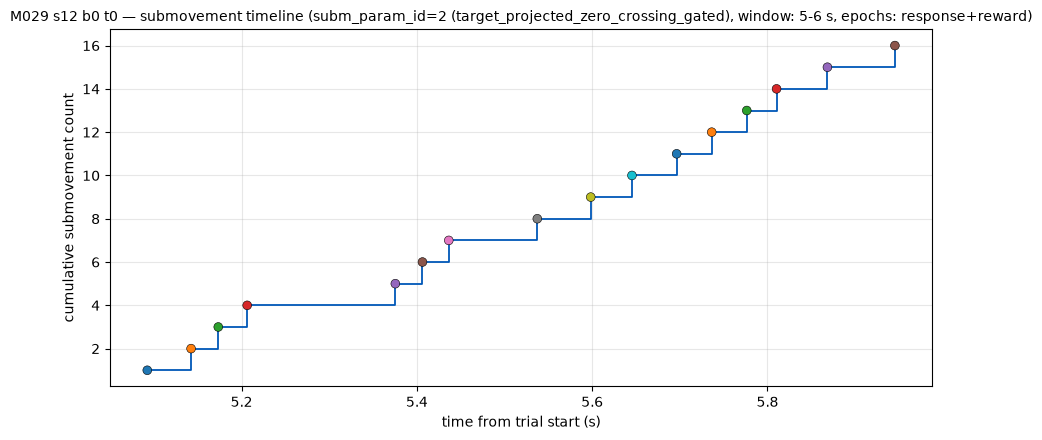

subject_id  session  block  n_trials  n_submovements  mean_peak_speed
      M029       12      0         1              16         0.189458

total: 16 submovements across 1 subject(s), 1 block(s) (submovements DataFrame left in the notebook namespace)


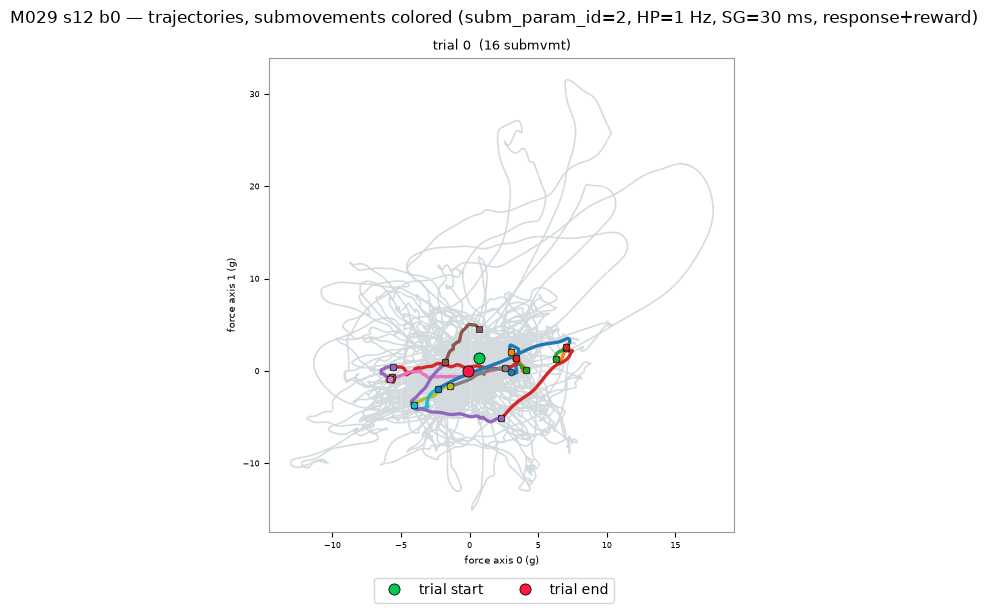

In [10]:
# ── Submovement detection: flexible subjects/sessions/blocks/trials, any subm_param_id ──
# Runs the actual detection algorithm for a chosen subm_param_id locally, on demand,
# across any combination of subjects/sessions/blocks/trials and restricted to a
# specific time range -- rather than reading whatever happens to already be populated
# in behavior_analysis.TrialSubmovements. Reproduces TrialSubmovements.make()'s
# preprocessing plus all three detection methods in ndnf_pipeline/behavior_analysis.py
# exactly (see the "Submovement detection methods" markdown cell above for what each
# subm_param_id means); nothing is written back to the DB. The resulting `submovements`
# DataFrame is left in the notebook namespace for further analysis in later cells.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids    = ['M029']   # list of subjects
sessions       = [12]     # None = every session for each subject; or a list, e.g. [,13,14,15,16,17,18]
blocks         = [0]      # None = every block in each session; or a list, e.g. [1, 2]
trials         = [0]       # None = every trial in each block; or a list, e.g. [,1,2,3,4,5]
time_range     = (5,6)       # None = whole trial; or (start_s, end_s) -- each touch epoch
                             # is clipped to this before detection runs on it (same
                             # convention used in the mechanics cells above)
epochs_to_include = ('response', 'reward')  # same vocabulary as
                             # GUIs/behavior_gui.py's EpochSelector -- when this doesn't
                             # cover the whole trial, each trial's touch epochs are
                             # further clipped to the selected epoch(s)' time range
                             # (intersected with time_range above, if that's also set)
subm_param_id  = 2         # which SubmovementDetectionParams row's algorithm to run --
                             # detection_method is fetched from the DB, so this cell
                             # automatically dispatches to whichever of the three methods
                             # below that row specifies
touch_param_id = 0          # TrialTouchTimes parameter set (must already be populated)
sat_param_id   = 0          # TrialSaturationTimes parameter set (must already be populated)
show_trajectory_plots = True  # force-space trajectory grid (submovements colored), one
                               # figure per (subject_id, session, block) -- turn off for a
                               # very large selection where that would mean many figures
n_cols         = 1          # trajectories per row in each grid
panel_size     = 6.0        # (inches) size of each trajectory panel in the grid
savgol_window_time = 0.03   # (s) Savitzky-Golay window length applied to each *displayed*
                             # force trace -- same convention as the joint-plot cell above.
                             # Display-only: detection itself still uses the pipeline's own
                             # boxcar smoothing (params['smooth_window_time']), so counts
                             # keep matching behavior_analysis.TrialSubmovements exactly.
savgol_polyorder   = 3       # polynomial order for the display-only Savitzky-Golay filter
highpass_cutoff_hz = 1       # (Hz) Butterworth high-pass cutoff removing baseline drift/bias
                             # from each trial's *displayed* force trace before Savitzky-Golay
                             # smoothing -- same convention as the joint-plot cell above.
                             # Display-only, like savgol_window_time/savgol_polyorder above:
                             # detection itself still uses the pipeline's own boxcar smoothing.
highpass_order     = 2       # Butterworth filter order (zero-phase via filtfilt)

TRAJ_COLOR   = '#cfd8dc'   # faint full-trial trajectory (background, for context)
START_COLOR  = '#00c853'   # start of trial
END_COLOR    = '#ff1744'   # end of trial
SUBM_CMAP    = plt.get_cmap('tab10')

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    def _as_list(x):
        """Normalize a parameter that should be a list into one -- lets subject_ids/
        sessions/blocks/trials above be set to a single value (e.g. sessions = 4)
        without the block/trial loop below failing on `for x in <int>`."""
        if x is None or isinstance(x, (list, tuple, np.ndarray)):
            return x
        return [x]

    subject_ids = _as_list(subject_ids)
    sessions = _as_list(sessions)
    blocks = _as_list(blocks)
    trials = _as_list(trials)

    params = (behavior_analysis.SubmovementDetectionParams() & {'subm_param_id': subm_param_id}).fetch1()
    print(f'subm_param_id={subm_param_id}: {params}')

    def _event_time_by_trial(key, event_type):
        """{trial: trial_event_time} for every trial in this block with this event type."""
        ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                              & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
        return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))

    def _savgol_smooth(values, dt, window_time, polyorder):
        """Savitzky-Golay-smooth a 1D trace given its sample interval `dt` (s). Display-only
        (see savgol_window_time/savgol_polyorder above) -- never used for detection."""
        from scipy.signal import savgol_filter
        if dt is None or dt <= 0 or len(values) < polyorder + 1:
            return values
        win = max(polyorder + 1, int(round(window_time / dt)))
        if win % 2 == 0:
            win += 1
        if win > len(values):
            win = len(values) if len(values) % 2 == 1 else len(values) - 1
        if win <= polyorder:
            return values
        return savgol_filter(values, window_length=win, polyorder=polyorder, mode='interp')

    def _highpass_filter(values, dt, cutoff_hz, order):
        """Zero-phase Butterworth high-pass filter removing baseline drift/bias from a
        *displayed* force trace, given its sample interval `dt` (s) -- same convention as
        the joint-plot cell above. Display-only, like _savgol_smooth: detection itself still
        uses the pipeline's own boxcar smoothing, so counts keep matching
        behavior_analysis.TrialSubmovements exactly. Skipped if the trace is too short for
        filtfilt's default edge padding."""
        if dt is None or dt <= 0:
            return values
        b, a = butter(order, cutoff_hz, btype='high', fs=1.0 / dt)
        padlen = 3 * max(len(a), len(b))
        if len(values) <= padlen:
            return values
        return filtfilt(b, a, values)

    def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                    trial_nums, trial_starts, trial_ends):
        """Per-trial (quiescence, response, reward) time windows, relative to trial
        start -- the same definition GUIs/behavior_gui.py's EpochSelector uses under the
        hood: quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing'
        (falls back to trial end); reward = 'reward' (falls back to 'threshold
        crossing') -> trial end. A trial missing the underlying event(s) simply has no
        entry for that epoch. Returns {trial: {epoch_name: (start, end)}}."""
        windows = {}
        for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
            trial = int(trial)
            duration = end - start
            window = {}
            go_t = go_by_trial.get(trial)
            threshold_t = threshold_by_trial.get(trial)
            reward_t = reward_by_trial.get(trial)
            if go_t is not None:
                window['quiescence'] = (0.0, go_t)
                window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
            reward_start = reward_t if reward_t is not None else threshold_t
            if reward_start is not None:
                window['reward'] = (reward_start, duration)
            windows[trial] = window
        return windows

    def _menger_curvature_radius(x, y, half_window=5):
        """Radius of curvature at each sample using the three-point Menger formula."""
        n = len(x)
        radius = np.full(n, np.inf)
        for i in range(half_window, n - half_window):
            x1, y1 = x[i - half_window], y[i - half_window]
            x2, y2 = x[i],               y[i]
            x3, y3 = x[i + half_window], y[i + half_window]
            a = np.hypot(x2 - x1, y2 - y1)
            b = np.hypot(x3 - x2, y3 - y2)
            c = np.hypot(x3 - x1, y3 - y1)
            area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
            if area > 1e-12:
                radius[i] = (a * b * c) / (4 * area)
        return radius


    def _lut_target_position(key):
        """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak for
        the block this trial (subject_id/session/trial in `key`) belongs to."""
        block = (experiment.BehaviorTrial() & key).fetch1('block')
        task_key = {'subject_id': key['subject_id'], 'session': key['session']}
        task_setting_id = (experiment.Block() & {**task_key, 'block': block}).fetch1('task_setting_id')
        lut = (experiment.TaskSettings() & {**task_key, 'task_setting_id': task_setting_id}).fetch1('target_force_lut')
        ax_idx, ax_val = (
            experiment.TaskSettings.ForceAxis() & {**task_key, 'task_setting_id': task_setting_id}
        ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
        fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
        peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
        return float(fa[0][peak_i]), float(fa[1][peak_j])


    def _merge_weak_submovements(all_subm, min_peak_speed=None, min_duration=None):
        """Fold any submovement that fails to clear `min_peak_speed` (g/sample) and/or
        `min_duration` (s) into the *next* segment, rather than counting it as a
        distinct submovement -- the subm_param_id=2 amplitude gate."""
        if not all_subm:
            return list(all_subm)
        merged = [dict(all_subm[0])]
        for seg in all_subm[1:]:
            prev = merged[-1]
            weak = ((min_peak_speed is not None and prev['peak_speed'] < min_peak_speed) or
                    (min_duration is not None and prev['duration'] < min_duration))
            if weak:
                seg = dict(seg)
                seg['start_time'] = prev['start_time']
                seg['duration']   = seg['end_time'] - seg['start_time']
                seg['peak_speed'] = max(prev['peak_speed'], seg['peak_speed'])
                merged[-1] = seg
            else:
                merged.append(dict(seg))
        return merged


    def _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """subm_param_id 0: a boundary is only accepted where a local minimum of speed
        and a local minimum of curvature radius co-occur within cooccurrence_window_time."""
        sample_interval = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
        cooc_win = max(1, int(params['cooccurrence_window_time'] / sample_interval))
        curv_hw = int(params['curvature_half_window'])
        curv_r = _menger_curvature_radius(f0, f1, half_window=curv_hw)

        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(mag))
            mag_ep = mag[j0:j1]
            curv_ep = curv_r[i0:i1]
            speed_mins, _ = find_peaks(-mag_ep, distance=min_dist, prominence=params['speed_prominence'])
            curv_mins, _ = find_peaks(-curv_ep, distance=min_dist)
            boundaries = set()
            for sm in speed_mins:
                for cm in curv_mins:
                    if abs(int(sm) - int(cm)) <= cooc_win:
                        boundaries.add((int(sm) + int(cm)) // 2)
                        break
            boundaries = sorted(boundaries)
            seg_starts = [0] + [b + 1 for b in boundaries]
            seg_ends = boundaries + [len(mag_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing(key, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """subm_param_id 1: a boundary wherever the velocity's projection onto the
        direction-to-target reverses sign."""
        tgt_f0, tgt_f1 = _lut_target_position(key)
        dx = tgt_f0 - f0
        dy = tgt_f1 - f1
        dist = np.clip(np.hypot(dx, dy), 1e-9, None)
        ux, uy = dx / dist, dy / dist
        vx = np.diff(f0)
        vy = np.diff(f1)
        proj = vx * ux[:-1] + vy * uy[:-1]

        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing_gated(key, params, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """subm_param_id 2: same rule as subm_param_id 1, plus a per-touch-epoch
        minimum-amplitude gate (_merge_weak_submovements)."""
        tgt_f0, tgt_f1 = _lut_target_position(key)
        dx = tgt_f0 - f0
        dy = tgt_f1 - f1
        dist = np.clip(np.hypot(dx, dy), 1e-9, None)
        ux, uy = dx / dist, dy / dist
        vx = np.diff(f0)
        vy = np.diff(f1)
        proj = vx * ux[:-1] + vy * uy[:-1]

        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            epoch_subm = []
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                epoch_subm.append({
                    'submovement_idx': 0,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
            epoch_subm = _merge_weak_submovements(epoch_subm, min_peak_speed=params['speed_prominence'])
            for seg in epoch_subm:
                seg['submovement_idx'] = subm_idx
                all_subm.append(seg)
                subm_idx += 1
        return all_subm


    def _detect_submovements(key, params, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """Dispatches on params['detection_method'], exactly like TrialSubmovements.make()."""
        method = params['detection_method']
        if method == 'speed_curvature_cooccurrence':
            return _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing':
            return _boundaries_target_projected_zero_crossing(key, f0, f1, t, mag, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing_gated':
            return _boundaries_target_projected_zero_crossing_gated(key, params, f0, f1, t, mag, touch_starts, touch_ends, min_dist)
        else:
            raise ValueError(f"Unknown detection_method {method!r} for subm_param_id={key.get('subm_param_id')}")


    def _boxcar_preprocess_trial(trace_key, smooth_window_time, min_submovement_duration):
        """Mirrors TrialSubmovements.make()'s preprocessing exactly: boxcar-smooth, then
        derive `mag`. Returns (f0, f1, t, mag, min_dist), or None if too little data."""
        force_trace_time = (experiment.TrialForceTrace() & trace_key).fetch1('force_trace_time')
        if len(force_trace_time) < 3:
            return None
        sample_interval = float(np.median(np.diff(force_trace_time)))
        smooth_window = max(1, int(round(smooth_window_time / sample_interval)))
        min_dist = max(2, int(round(min_submovement_duration / sample_interval)))
        half_w = smooth_window // 2

        ax_idx, ax_val = (
            experiment.TrialForceTrace.TrialForceAxis() & trace_key & 'force_axis_idx < 2'
        ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
        if len(ax_idx) < 2:
            return None
        f_raw = {int(i): np.asarray(v, dtype=float) for i, v in zip(ax_idx, ax_val)}
        f_smooth = {ax: np.convolve(f_raw[ax], np.ones(smooth_window) / smooth_window, mode='valid')
                    for ax in f_raw}
        n = min(len(v) for v in f_smooth.values())
        if n < 2:
            return None
        f0, f1 = f_smooth[0][:n], f_smooth[1][:n]
        t = force_trace_time[half_w: half_w + n]
        if len(t) < n:
            t = force_trace_time[0] + np.arange(n) * sample_interval
        mag = np.sqrt(np.diff(f0) ** 2 + np.diff(f1) ** 2)
        return f0, f1, t, mag, min_dist


    # resolve subjects/sessions/blocks/trials into concrete combinations and run detection
    rows = []
    for subject_id in subject_ids:
        sessions_this = sessions if sessions is not None else sorted(
            (experiment.Session() & {'subject_id': subject_id}).fetch('session').tolist())
        for session in sessions_this:
            blocks_this = blocks if blocks is not None else sorted(
                (experiment.Block() & {'subject_id': subject_id, 'session': session}).fetch('block').tolist())
            for block in blocks_this:
                block_key = {'subject_id': subject_id, 'session': session, 'block': block}
                trials_this = trials if trials is not None else sorted(
                    (experiment.BehaviorTrial() & block_key).fetch('trial').tolist())

                # epoch windows, fetched once per block rather than per trial
                go_by_trial = _event_time_by_trial(block_key, 'go')
                threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
                reward_by_trial = _event_time_by_trial(block_key, 'reward')
                trial_nums_all, trial_starts_all, trial_ends_all = (
                    experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
                ).fetch('trial', 'trial_start_time', 'trial_end_time')
                epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                            trial_nums_all, trial_starts_all, trial_ends_all)

                for trial in trials_this:
                    trial = int(trial)
                    trace_key = {**block_key, 'trial': trial}
                    pre = _boxcar_preprocess_trial(trace_key, params['smooth_window_time'],
                                                    params['min_submovement_duration'])
                    if pre is None:
                        continue
                    f0, f1, t, mag, min_dist = pre

                    touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
                    touch_starts, touch_ends = (
                        behavior_analysis.TrialTouchTimes.TouchEpoch()
                        & touch_key & {'is_touch': True}
                    ).fetch('start_time', 'end_time', order_by='epoch_idx')

                    # combine time_range with the selected epoch(s)' bound for this
                    # trial into a single effective_range, then clip each touch epoch to
                    # it (same convention as the mechanics cells above); a touch epoch
                    # entirely outside effective_range drops out. Non-adjacent epoch
                    # selections (e.g. quiescence + reward, skipping response) use the
                    # outer bound, not a perfect exclusion of the gap between them.
                    effective_range = time_range
                    if epochs_to_include:
                        epoch_window = epoch_windows.get(trial, {})
                        epoch_bounds = [epoch_window[e] for e in epochs_to_include if e in epoch_window]
                        if epoch_bounds:
                            epoch_lo = min(b[0] for b in epoch_bounds)
                            epoch_hi = max(b[1] for b in epoch_bounds)
                            effective_range = (max(effective_range[0], epoch_lo), min(effective_range[1], epoch_hi)) \
                                if effective_range is not None else (epoch_lo, epoch_hi)

                    if effective_range is not None:
                        clipped_starts, clipped_ends = [], []
                        for st, en in zip(touch_starts, touch_ends):
                            st_c = max(float(st), effective_range[0])
                            en_c = min(float(en), effective_range[1])
                            if en_c > st_c:
                                clipped_starts.append(st_c)
                                clipped_ends.append(en_c)
                        touch_starts = np.array(clipped_starts)
                        touch_ends = np.array(clipped_ends)

                    detect_key = {**trace_key, 'touch_param_id': touch_param_id,
                                  'sat_param_id': sat_param_id, 'subm_param_id': subm_param_id}
                    all_subm = _detect_submovements(detect_key, params, f0, f1, t, mag,
                                                     touch_starts, touch_ends, min_dist)
                    for seg in all_subm:
                        rows.append({'subject_id': subject_id, 'session': session, 'block': block,
                                     'trial': trial, **seg})

    submovements = pd.DataFrame(rows)

    if len(submovements) == 0:
        print('No submovements detected for the given selection.')
    else:
        time_range_label = 'whole trial' if time_range is None else f'{time_range[0]:g}-{time_range[1]:g} s'
        epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
        window_title = (f"subm_param_id={subm_param_id} ({params['detection_method']}), "
                         f'window: {time_range_label}, epochs: {epoch_label}')

        # if a single specific trial is selected, show how its submovements unfold across
        # time (cumulative count vs. time from trial start); otherwise, no summary plot
        # here (see the trajectory grids below, and the printed summary table above)
        single_trial_selected = trials is not None and len(trials) == 1

        if single_trial_selected:
            for (g_subject, g_session, g_block), grp in submovements.groupby(['subject_id', 'session', 'block']):
                grp_sorted = grp.sort_values('start_time')
                cumulative = np.arange(1, len(grp_sorted) + 1)
                colors = [SUBM_CMAP(int(idx) % 10) for idx in grp_sorted['submovement_idx']]

                fig, ax = plt.subplots(figsize=(9, 4.5))
                ax.step(grp_sorted['start_time'], cumulative, where='post', color='#0057b8', lw=1.3, zorder=2)
                ax.scatter(grp_sorted['start_time'], cumulative, c=colors, s=40,
                           edgecolors='black', linewidths=0.4, zorder=3)
                ax.set_xlabel('time from trial start (s)')
                ax.set_ylabel('cumulative submovement count')
                ax.set_title(f'{g_subject} s{g_session} b{g_block} t{int(trials[0])} '
                             f'— submovement timeline ({window_title})',
                             fontsize=10)
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

        summary = submovements.groupby(['subject_id', 'session', 'block']).agg(
            n_trials=('trial', 'nunique'),
            n_submovements=('submovement_idx', 'count'),
            mean_peak_speed=('peak_speed', 'mean'),
        ).reset_index()
        print(summary.to_string(index=False))
        print(f'\ntotal: {len(submovements)} submovements across '
              f'{submovements["subject_id"].nunique()} subject(s), '
              f'{submovements.groupby(["subject_id", "session", "block"]).ngroups} block(s) '
              f'(submovements DataFrame left in the notebook namespace)')

        # ── force-space trajectories, submovements colored -- one grid per (subject, session,
        # block). Each trial's raw force trace is high-pass filtered (baseline drift/bias
        # removal) then Savitzky-Golay-smoothed for display -- same convention as the
        # joint-plot cell above -- with the already-detected submovements from `submovements`
        # overlaid on top. No target_force_lut background here: high-pass filtering removes
        # the near-DC/sustained-position component of the trace, so the displayed trajectory
        # no longer sits at its true absolute position relative to the target ──
        if show_trajectory_plots:
            for (g_subject, g_session, g_block), grp in submovements.groupby(['subject_id', 'session', 'block']):
                trials_in_group = sorted(grp['trial'].unique())
                group_block_key = {'subject_id': g_subject, 'session': g_session, 'block': g_block}

                n_rows = int(np.ceil(len(trials_in_group) / n_cols))
                fig, axes = plt.subplots(n_rows, n_cols, figsize=(panel_size * n_cols, panel_size * n_rows), squeeze=False)
                fig.patch.set_facecolor('white')
                fig.subplots_adjust(hspace=0.6, wspace=0.5, top=0.9)
                fig.suptitle(f'{g_subject} s{g_session} b{g_block} — trajectories, submovements colored '
                             f'(subm_param_id={subm_param_id}, HP={highpass_cutoff_hz:g} Hz, '
                             f'SG={savgol_window_time*1000:g} ms, {epoch_label})',
                             fontsize=12)

                for i, trial in enumerate(trials_in_group):
                    ax = axes[i // n_cols, i % n_cols]
                    trial = int(trial)
                    trace_key = {**group_block_key, 'trial': trial}

                    ax_idx, times, ax_val = (
                        experiment.TrialForceTrace() * experiment.TrialForceTrace.TrialForceAxis()
                        & trace_key & 'force_axis_idx < 2'
                    ).fetch('force_axis_idx', 'force_trace_time', 'force_trace_value', order_by='force_axis_idx')
                    if len(ax_idx) < 2 or any(len(np.asarray(v, dtype=float)) == 0 for v in ax_val[:len(ax_idx)]):
                        ax.set_visible(False)
                        continue

                    idx0 = list(ax_idx).index(0)
                    idx1 = list(ax_idx).index(1)
                    f0_raw = np.asarray(ax_val[idx0], dtype=float)
                    f1_raw = np.asarray(ax_val[idx1], dtype=float)
                    t_raw = np.asarray(times[idx0], dtype=float)
                    if len(f0_raw) < 2 or len(t_raw) < 2:
                        ax.set_visible(False)
                        continue

                    dt = float(np.median(np.diff(t_raw))) if len(t_raw) > 1 else None
                    f0_hp = _highpass_filter(f0_raw, dt, highpass_cutoff_hz, highpass_order)
                    f1_hp = _highpass_filter(f1_raw, dt, highpass_cutoff_hz, highpass_order)
                    f0_smooth = _savgol_smooth(f0_hp, dt, savgol_window_time, savgol_polyorder)
                    f1_smooth = _savgol_smooth(f1_hp, dt, savgol_window_time, savgol_polyorder)

                    ax.plot(f0_smooth, f1_smooth, '-', color=TRAJ_COLOR, lw=1.2, alpha=0.9, zorder=1)

                    # submovements already detected above (start/end times are relative to
                    # the pipeline-matching boxcar-smoothed trace, but t_raw shares the same
                    # trial-start-relative timeline, so searchsorted maps correctly onto this
                    # high-pass filtered, Savitzky-Golay-smoothed display trace too)
                    trial_subm = grp[grp['trial'] == trial].sort_values('submovement_idx')
                    for _, seg in trial_subm.iterrows():
                        j0 = int(np.searchsorted(t_raw, seg['start_time']))
                        j1 = min(int(np.searchsorted(t_raw, seg['end_time'])), len(f0_smooth) - 1)
                        if j1 <= j0:
                            continue
                        color = SUBM_CMAP(int(seg['submovement_idx']) % 10)
                        ax.plot(f0_smooth[j0:j1 + 1], f1_smooth[j0:j1 + 1], '-', color=color, lw=2.4, zorder=3)
                        ax.plot(f0_smooth[j0], f1_smooth[j0], 'o', color=color, ms=5, mec='black', mew=0.4, zorder=4)
                        ax.plot(f0_smooth[j1], f1_smooth[j1], 's', color=color, ms=5, mec='black', mew=0.4, zorder=4)

                    ax.plot(f0_smooth[0], f1_smooth[0], 'o', color=START_COLOR, ms=8,
                            mec='black', mew=0.6, zorder=5, label='trial start')
                    ax.plot(f0_smooth[-1], f1_smooth[-1], 'o', color=END_COLOR, ms=8,
                            mec='black', mew=0.6, zorder=5, label='trial end')

                    ax.set_title(f'trial {trial}  ({len(trial_subm)} submvmt)', fontsize=9)
                    ax.set_xlabel('force axis 0 (g)', fontsize=7)
                    ax.set_ylabel('force axis 1 (g)', fontsize=7)
                    ax.tick_params(labelsize=6)
                    ax.grid(True, color='white', alpha=0.3, linewidth=0.8, zorder=2)
                    for spine in ax.spines.values():
                        spine.set_color('#999999')

                for j in range(len(trials_in_group), n_rows * n_cols):
                    axes[j // n_cols, j % n_cols].set_visible(False)

                handles, labels = axes[0, 0].get_legend_handles_labels()
                if handles:
                    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
                               bbox_to_anchor=(0.5, -0.02))
                plt.show()

Toward vs. away submovements per trial (specific block(s), one session)

subm_param_id=2: {'subm_param_id': 2, 'detection_method': 'target_projected_zero_crossing_gated', 'smooth_window_time': 0.03, 'curvature_half_window': 0, 'min_submovement_duration': 0.03, 'speed_prominence': 0.05, 'cooccurrence_window_time': 0.0}
 block  trial direction  n_submovements  total_duration  mean_peak_speed
     0      0      away              72        3.618976         0.147269
     0      0    toward              74        3.367936         0.148906
     0      1      away              64        3.074816         0.109395
     0      1    toward              82        3.350912         0.092960
     0      2      away              43        1.913792         0.106050
     0      2    toward              53        2.234080         0.106680
     0      3      away              54        2.473760         0.106361
     0      3    toward              72        2.557888         0.093779
     0      4      away              49        2.237984         0.076623
     0      4    toward

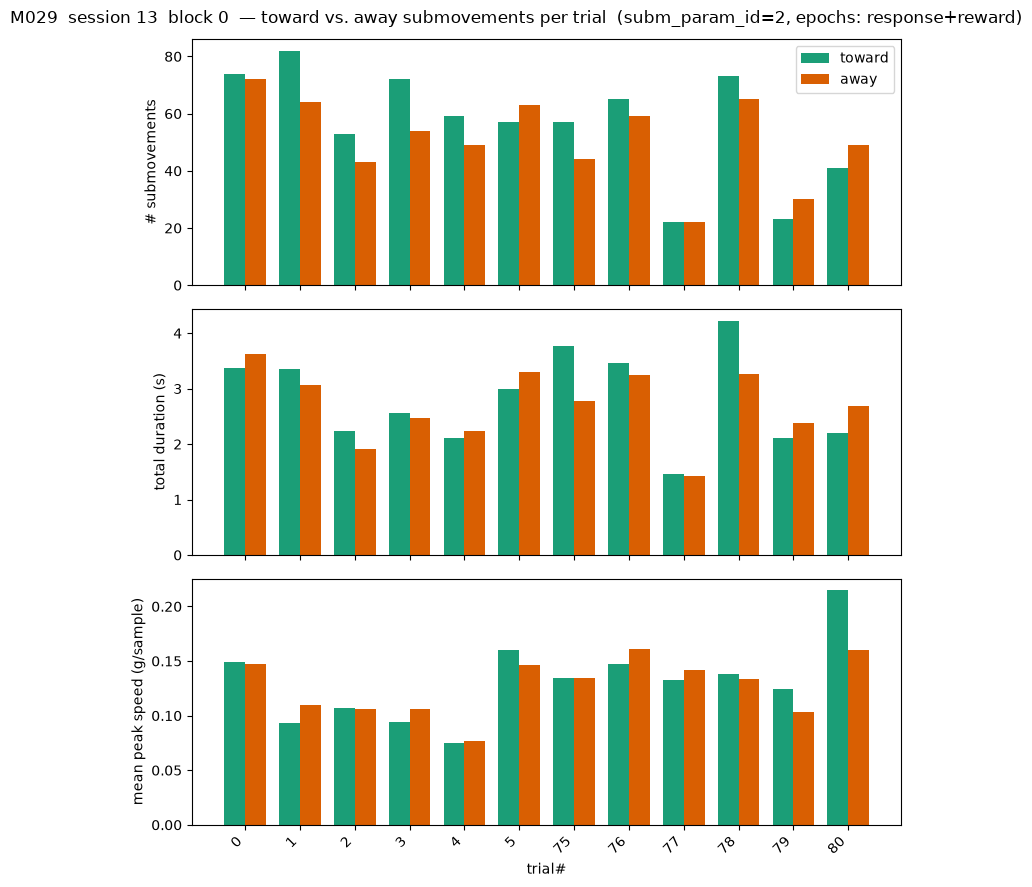

In [11]:
# ── Toward vs. away submovements per trial: specific block(s) in one session ──
# Reuses TrialSubmovements.make()'s exact preprocessing/detection (reproduced locally,
# same as the "SUBMOVEMENT ANALYSIS FINAL" cell above, so no subm_param_id has to
# already be populated in the DB), then classifies every detected submovement as
# 'toward' or 'away' from the block's target_force_lut peak: the mean force-velocity,
# projected onto the direction from the current force position to the target, over
# the segment's [start_time, end_time] (mean_proj > 0 -> net progress toward the
# target; <= 0 -> away). For subm_param_id 1/2 (target_projected_zero_crossing[_gated])
# this reproduces the exact sign that defined the segment boundaries in the first
# place, so submovements strictly alternate toward/away; for subm_param_id 0
# (speed_curvature_cooccurrence) it is a post-hoc label on boundaries defined by
# speed/curvature instead. Compares submovement count, total duration, and mean peak
# speed -- toward vs. away -- per trial, for one or more blocks in one session.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ── parameters ───────────────────────────────────────────────────────────────
subject_id        = 'M029'
session           = 13            # single session
blocks_to_analyze = [0]          # list of blocks -- e.g. [1, 3] to compare multiple
trials            = [0,1,2,3,4,5] + [75,76,77,78,79,80]       # None = every trial in each block; or a list, e.g. [3, 4, 10]
subm_param_id     = 2            # SubmovementDetectionParams row whose algorithm to run --
                                  # 1 or 2 (target_projected_zero_crossing[_gated]) give the
                                  # cleanest toward/away split, since direction is exactly
                                  # what defines their segment boundaries
touch_param_id    = 0            # TrialTouchTimes parameter set (must already be populated)
sat_param_id      = 0            # TrialSaturationTimes parameter set (must already be populated)
epochs_to_include = ('response', 'reward')  # same vocabulary as GUIs/behavior_gui.py's
                                  # EpochSelector -- restricts each trial's touch epochs
                                  # (and hence submovement detection) to these

TOWARD_COLOR = '#1b9e77'
AWAY_COLOR   = '#d95f02'

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    def _event_time_by_trial(key, event_type):
        """{trial: trial_event_time} for every trial in this block with this event type."""
        ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                              & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
        return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


    def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                    trial_nums, trial_starts, trial_ends):
        """Per-trial (quiescence, response, reward) time windows, relative to trial
        start -- the same definition GUIs/behavior_gui.py's EpochSelector uses under the
        hood: quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing'
        (falls back to trial end); reward = 'reward' (falls back to 'threshold
        crossing') -> trial end. Returns {trial: {epoch_name: (start, end)}}."""
        windows = {}
        for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
            trial = int(trial)
            duration = end - start
            window = {}
            go_t = go_by_trial.get(trial)
            threshold_t = threshold_by_trial.get(trial)
            reward_t = reward_by_trial.get(trial)
            if go_t is not None:
                window['quiescence'] = (0.0, go_t)
                window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
            reward_start = reward_t if reward_t is not None else threshold_t
            if reward_start is not None:
                window['reward'] = (reward_start, duration)
            windows[trial] = window
        return windows


    def _menger_curvature_radius(x, y, half_window=5):
        """Radius of curvature at each sample using the three-point Menger formula."""
        n = len(x)
        radius = np.full(n, np.inf)
        for i in range(half_window, n - half_window):
            x1, y1 = x[i - half_window], y[i - half_window]
            x2, y2 = x[i],               y[i]
            x3, y3 = x[i + half_window], y[i + half_window]
            a = np.hypot(x2 - x1, y2 - y1)
            b = np.hypot(x3 - x2, y3 - y2)
            c = np.hypot(x3 - x1, y3 - y1)
            area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
            if area > 1e-12:
                radius[i] = (a * b * c) / (4 * area)
        return radius


    def _lut_target_position(key):
        """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak for
        the block this trial (subject_id/session/trial in `key`) belongs to."""
        block = (experiment.BehaviorTrial() & key).fetch1('block')
        task_key = {'subject_id': key['subject_id'], 'session': key['session']}
        task_setting_id = (experiment.Block() & {**task_key, 'block': block}).fetch1('task_setting_id')
        lut = (experiment.TaskSettings() & {**task_key, 'task_setting_id': task_setting_id}).fetch1('target_force_lut')
        ax_idx, ax_val = (
            experiment.TaskSettings.ForceAxis() & {**task_key, 'task_setting_id': task_setting_id}
        ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
        fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
        peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
        return float(fa[0][peak_i]), float(fa[1][peak_j])


    def _merge_weak_submovements(all_subm, min_peak_speed=None, min_duration=None):
        """Fold any submovement that fails to clear `min_peak_speed` and/or
        `min_duration` into the *next* segment -- the subm_param_id=2 amplitude gate."""
        if not all_subm:
            return list(all_subm)
        merged = [dict(all_subm[0])]
        for seg in all_subm[1:]:
            prev = merged[-1]
            weak = ((min_peak_speed is not None and prev['peak_speed'] < min_peak_speed) or
                    (min_duration is not None and prev['duration'] < min_duration))
            if weak:
                seg = dict(seg)
                seg['start_time'] = prev['start_time']
                seg['duration']   = seg['end_time'] - seg['start_time']
                seg['peak_speed'] = max(prev['peak_speed'], seg['peak_speed'])
                merged[-1] = seg
            else:
                merged.append(dict(seg))
        return merged


    def _boxcar_preprocess_trial(trace_key, smooth_window_time, min_submovement_duration):
        """Mirrors TrialSubmovements.make()'s preprocessing exactly: boxcar-smooth, then
        derive `mag`. Returns (f0, f1, t, mag, min_dist), or None if too little data."""
        force_trace_time = (experiment.TrialForceTrace() & trace_key).fetch1('force_trace_time')
        if len(force_trace_time) < 3:
            return None
        sample_interval = float(np.median(np.diff(force_trace_time)))
        smooth_window = max(1, int(round(smooth_window_time / sample_interval)))
        min_dist = max(2, int(round(min_submovement_duration / sample_interval)))
        half_w = smooth_window // 2

        ax_idx, ax_val = (
            experiment.TrialForceTrace.TrialForceAxis() & trace_key & 'force_axis_idx < 2'
        ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
        if len(ax_idx) < 2:
            return None
        f_raw = {int(i): np.asarray(v, dtype=float) for i, v in zip(ax_idx, ax_val)}
        f_smooth = {ax: np.convolve(f_raw[ax], np.ones(smooth_window) / smooth_window, mode='valid')
                    for ax in f_raw}
        n = min(len(v) for v in f_smooth.values())
        if n < 2:
            return None
        f0, f1 = f_smooth[0][:n], f_smooth[1][:n]
        t = force_trace_time[half_w: half_w + n]
        if len(t) < n:
            t = force_trace_time[0] + np.arange(n) * sample_interval
        mag = np.sqrt(np.diff(f0) ** 2 + np.diff(f1) ** 2)
        return f0, f1, t, mag, min_dist


    def _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """subm_param_id 0: a boundary is only accepted where a local minimum of speed
        and a local minimum of curvature radius co-occur within cooccurrence_window_time."""
        sample_interval = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
        cooc_win = max(1, int(params['cooccurrence_window_time'] / sample_interval))
        curv_hw = int(params['curvature_half_window'])
        curv_r = _menger_curvature_radius(f0, f1, half_window=curv_hw)

        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(mag))
            mag_ep = mag[j0:j1]
            curv_ep = curv_r[i0:i1]
            speed_mins, _ = find_peaks(-mag_ep, distance=min_dist, prominence=params['speed_prominence'])
            curv_mins, _ = find_peaks(-curv_ep, distance=min_dist)
            boundaries = set()
            for sm in speed_mins:
                for cm in curv_mins:
                    if abs(int(sm) - int(cm)) <= cooc_win:
                        boundaries.add((int(sm) + int(cm)) // 2)
                        break
            boundaries = sorted(boundaries)
            seg_starts = [0] + [b + 1 for b in boundaries]
            seg_ends = boundaries + [len(mag_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing(f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """subm_param_id 1: a boundary wherever the velocity's projection onto the
        direction-to-target reverses sign."""
        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing_gated(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """subm_param_id 2: same rule as subm_param_id 1, plus a per-touch-epoch
        minimum-amplitude gate (_merge_weak_submovements)."""
        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            epoch_subm = []
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                epoch_subm.append({
                    'submovement_idx': 0,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
            epoch_subm = _merge_weak_submovements(epoch_subm, min_peak_speed=params['speed_prominence'])
            for seg in epoch_subm:
                seg['submovement_idx'] = subm_idx
                all_subm.append(seg)
                subm_idx += 1
        return all_subm


    def _detect_submovements(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """Dispatches on params['detection_method'], exactly like TrialSubmovements.make()."""
        method = params['detection_method']
        if method == 'speed_curvature_cooccurrence':
            return _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing':
            return _boundaries_target_projected_zero_crossing(f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing_gated':
            return _boundaries_target_projected_zero_crossing_gated(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)
        else:
            raise ValueError(f"Unknown detection_method {method!r} for subm_param_id={subm_param_id}")


    params = (behavior_analysis.SubmovementDetectionParams() & {'subm_param_id': subm_param_id}).fetch1()
    print(f'subm_param_id={subm_param_id}: {params}')

    rows = []
    for block in blocks_to_analyze:
        block_key = {'subject_id': subject_id, 'session': session, 'block': block}
        trials_this = trials if trials is not None else sorted(
            (experiment.BehaviorTrial() & block_key).fetch('trial').tolist())

        # epoch windows, fetched once per block rather than per trial
        go_by_trial = _event_time_by_trial(block_key, 'go')
        threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
        reward_by_trial = _event_time_by_trial(block_key, 'reward')
        trial_nums_all, trial_starts_all, trial_ends_all = (
            experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
        ).fetch('trial', 'trial_start_time', 'trial_end_time')
        epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                    trial_nums_all, trial_starts_all, trial_ends_all)

        for trial in trials_this:
            trial = int(trial)
            trace_key = {**block_key, 'trial': trial}
            pre = _boxcar_preprocess_trial(trace_key, params['smooth_window_time'],
                                            params['min_submovement_duration'])
            if pre is None:
                continue
            f0, f1, t, mag, min_dist = pre

            touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
            touch_starts, touch_ends = (
                behavior_analysis.TrialTouchTimes.TouchEpoch()
                & touch_key & {'is_touch': True}
            ).fetch('start_time', 'end_time', order_by='epoch_idx')

            # clip each touch epoch to the selected epoch(s)' time range, same
            # convention as the "SUBMOVEMENT ANALYSIS FINAL" cell above
            if epochs_to_include:
                epoch_window = epoch_windows.get(trial, {})
                epoch_bounds = [epoch_window[e] for e in epochs_to_include if e in epoch_window]
                if epoch_bounds:
                    epoch_lo = min(b[0] for b in epoch_bounds)
                    epoch_hi = max(b[1] for b in epoch_bounds)
                    clipped_starts, clipped_ends = [], []
                    for st, en in zip(touch_starts, touch_ends):
                        st_c, en_c = max(float(st), epoch_lo), min(float(en), epoch_hi)
                        if en_c > st_c:
                            clipped_starts.append(st_c)
                            clipped_ends.append(en_c)
                    touch_starts, touch_ends = np.array(clipped_starts), np.array(clipped_ends)

            # target-projected velocity -- used both by subm_param_id 1/2's own
            # boundary detection, and (for every subm_param_id) as the post-hoc
            # toward/away label on each detected segment below
            tgt_f0, tgt_f1 = _lut_target_position(trace_key)
            dx, dy = tgt_f0 - f0, tgt_f1 - f1
            dist = np.clip(np.hypot(dx, dy), 1e-9, None)
            ux, uy = dx / dist, dy / dist
            vx, vy = np.diff(f0), np.diff(f1)
            proj = vx * ux[:-1] + vy * uy[:-1]

            all_subm = _detect_submovements(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)

            for seg in all_subm:
                i0 = int(np.searchsorted(t, seg['start_time']))
                i1 = min(int(np.searchsorted(t, seg['end_time'])), len(proj))
                seg_proj = proj[i0:i1] if i1 > i0 else proj[i0:i0 + 1]
                mean_proj = float(np.mean(seg_proj)) if len(seg_proj) else 0.0
                rows.append({
                    'subject_id': subject_id, 'session': session, 'block': block, 'trial': trial,
                    **seg,
                    'mean_proj': mean_proj,
                    'direction': 'toward' if mean_proj > 0 else 'away',
                })

    submovements_dir = pd.DataFrame(rows)

    if len(submovements_dir) == 0:
        print('No submovements detected for the given selection.')
    else:
        epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'

        # ── per-trial, per-direction summary ────────────────────────────────────
        per_trial = submovements_dir.groupby(['block', 'trial', 'direction']).agg(
            n_submovements=('submovement_idx', 'count'),
            total_duration=('duration', 'sum'),
            mean_peak_speed=('peak_speed', 'mean'),
        ).reset_index()

        print(per_trial.to_string(index=False))

        overall = submovements_dir.groupby(['block', 'direction']).agg(
            n_trials=('trial', 'nunique'),
            n_submovements=('submovement_idx', 'count'),
            total_duration=('duration', 'sum'),
            mean_duration=('duration', 'mean'),
            mean_peak_speed=('peak_speed', 'mean'),
        ).reset_index()
        print(f'\noverall toward vs. away, per block ({subject_id} session {session}, subm_param_id={subm_param_id}):')
        print(overall.to_string(index=False))

        # ── comparison plot: one figure per block, trials on the x-axis ────────
        for block in blocks_to_analyze:
            block_summary = per_trial[per_trial['block'] == block]
            if len(block_summary) == 0:
                print(f'block {block}: no submovements to plot')
                continue

            all_trials_block = sorted(block_summary['trial'].unique())
            toward = block_summary[block_summary['direction'] == 'toward'].set_index('trial')
            away = block_summary[block_summary['direction'] == 'away'].set_index('trial')
            toward = toward.reindex(all_trials_block, fill_value=0)
            away = away.reindex(all_trials_block, fill_value=0)

            x = np.arange(len(all_trials_block))
            bar_w = 0.38

            fig, axes = plt.subplots(3, 1, figsize=(max(8, 0.5 * len(all_trials_block)), 9), sharex=True)
            fig.suptitle(f'{subject_id}  session {session}  block {block}  '
                         f'— toward vs. away submovements per trial  '
                         f'(subm_param_id={subm_param_id}, epochs: {epoch_label})', fontsize=12)

            axes[0].bar(x - bar_w / 2, toward['n_submovements'], width=bar_w, color=TOWARD_COLOR, label='toward')
            axes[0].bar(x + bar_w / 2, away['n_submovements'], width=bar_w, color=AWAY_COLOR, label='away')
            axes[0].set_ylabel('# submovements')
            axes[0].legend()

            axes[1].bar(x - bar_w / 2, toward['total_duration'], width=bar_w, color=TOWARD_COLOR)
            axes[1].bar(x + bar_w / 2, away['total_duration'], width=bar_w, color=AWAY_COLOR)
            axes[1].set_ylabel('total duration (s)')

            axes[2].bar(x - bar_w / 2, toward['mean_peak_speed'], width=bar_w, color=TOWARD_COLOR)
            axes[2].bar(x + bar_w / 2, away['mean_peak_speed'], width=bar_w, color=AWAY_COLOR)
            axes[2].set_ylabel('mean peak speed (g/sample)')
            axes[2].set_xlabel('trial#')
            axes[2].set_xticks(x)
            axes[2].set_xticklabels(all_trials_block, rotation=45, ha='right')

            plt.tight_layout()
            plt.show()

        # `submovements_dir` (per-submovement, with `direction`/`mean_proj` columns) and
        # `per_trial` (per-trial, per-direction summary) are left in the notebook
        # namespace for further analysis.

Time to reward & submovements toward target, per trial (block(s), one session)

subm_param_id=2: {'subm_param_id': 2, 'detection_method': 'target_projected_zero_crossing_gated', 'smooth_window_time': 0.03, 'curvature_half_window': 0, 'min_submovement_duration': 0.03, 'speed_prominence': 0.05, 'cooccurrence_window_time': 0.0}
 block  trial  time_to_reward  n_toward  n_away  n_total
     0      0        34.32198        74      72      146
     0      1        35.79398        82      64      146
     0      2        27.46000        53      43       96
     0      3         6.63002        72      54      126
     0      4         8.47398        59      49      108
     0      5         7.72800        57      63      120
     0     75        48.79600        57      44      101
     0     76         3.85200        65      59      124
     0     77         7.83402        22      22       44
     0     78        37.55002        73      65      138
     0     79        26.12400        23      30       53


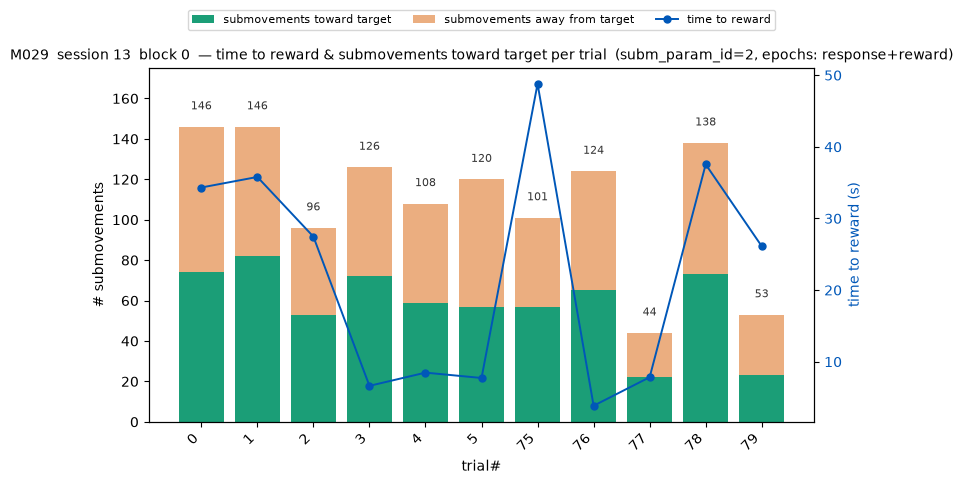

In [13]:
# ── Time to reward + submovements toward target, per trial: block(s) in one session ──
# For each trial in the selected block(s), plots time-to-reward (line, left axis)
# alongside the number of submovements moving toward the block's target_force_lut
# peak (stacked bar, right axis): the 'toward' portion is drawn solid, the 'away'
# portion is stacked on top so the full bar height reads off as the total number of
# submovements, and the total is also printed as a text label above each bar. Reuses
# the same local reproduction of TrialSubmovements.make() (and the toward/away
# projection rule) as the "Toward vs. away submovements per trial" cell above -- no
# subm_param_id has to already be populated in the DB.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ── parameters ───────────────────────────────────────────────────────────────
subject_id        = 'M029'
session           = 13            # single session
blocks_to_analyze = [0]          # list of blocks -- e.g. [1, 3] to compare multiple
trials            = [0,1,2,3,4,5] + [75,76,77,78,79]     # None = every trial in each block; or a list, e.g. [3, 4, 10]
subm_param_id     = 2            # SubmovementDetectionParams row whose algorithm to run --
                                  # 1 or 2 (target_projected_zero_crossing[_gated]) give the
                                  # cleanest toward/away split, since direction is exactly
                                  # what defines their segment boundaries
touch_param_id    = 0            # TrialTouchTimes parameter set (must already be populated)
sat_param_id      = 0            # TrialSaturationTimes parameter set (must already be populated)
epochs_to_include = ('response', 'reward')  # same vocabulary as GUIs/behavior_gui.py's
                                  # EpochSelector -- restricts each trial's touch epochs
                                  # (and hence submovement detection) to these; time-to-
                                  # reward itself is unaffected (it comes straight from
                                  # trial events, not from the submovement detection window)

TOWARD_COLOR = '#1b9e77'
AWAY_COLOR   = '#d95f02'
TTR_COLOR    = '#0057b8'

if 'experiment' not in globals() or 'behavior_analysis' not in globals():
    print("`experiment`/`behavior_analysis` are not defined in this notebook; skipping. "
          "Run the cell that creates or imports the schemas first.")
else:
    def _event_time_by_trial(key, event_type):
        """{trial: trial_event_time} for every trial in this block with this event type."""
        ev_trial, ev_time = (experiment.TrialEvent() * experiment.BehaviorTrial() * experiment.Block()
                              & {**key, 'trial_event_type': event_type}).fetch('trial', 'trial_event_time')
        return dict(zip(ev_trial.tolist(), np.asarray(ev_time, float)))


    def _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                    trial_nums, trial_starts, trial_ends):
        """Per-trial (quiescence, response, reward) time windows, relative to trial
        start -- the same definition GUIs/behavior_gui.py's EpochSelector uses under the
        hood: quiescence = trial start -> 'go'; response = 'go' -> 'threshold crossing'
        (falls back to trial end); reward = 'reward' (falls back to 'threshold
        crossing') -> trial end. Returns {trial: {epoch_name: (start, end)}}."""
        windows = {}
        for trial, start, end in zip(trial_nums, np.asarray(trial_starts, float), np.asarray(trial_ends, float)):
            trial = int(trial)
            duration = end - start
            window = {}
            go_t = go_by_trial.get(trial)
            threshold_t = threshold_by_trial.get(trial)
            reward_t = reward_by_trial.get(trial)
            if go_t is not None:
                window['quiescence'] = (0.0, go_t)
                window['response'] = (go_t, threshold_t if threshold_t is not None else duration)
            reward_start = reward_t if reward_t is not None else threshold_t
            if reward_start is not None:
                window['reward'] = (reward_start, duration)
            windows[trial] = window
        return windows


    def _menger_curvature_radius(x, y, half_window=5):
        """Radius of curvature at each sample using the three-point Menger formula."""
        n = len(x)
        radius = np.full(n, np.inf)
        for i in range(half_window, n - half_window):
            x1, y1 = x[i - half_window], y[i - half_window]
            x2, y2 = x[i],               y[i]
            x3, y3 = x[i + half_window], y[i + half_window]
            a = np.hypot(x2 - x1, y2 - y1)
            b = np.hypot(x3 - x2, y3 - y2)
            c = np.hypot(x3 - x1, y3 - y1)
            area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
            if area > 1e-12:
                radius[i] = (a * b * c) / (4 * area)
        return radius


    def _lut_target_position(key):
        """(tgt_f0, tgt_f1): force-axis-0/1 coordinates of the target_force_lut peak for
        the block this trial (subject_id/session/trial in `key`) belongs to."""
        block = (experiment.BehaviorTrial() & key).fetch1('block')
        task_key = {'subject_id': key['subject_id'], 'session': key['session']}
        task_setting_id = (experiment.Block() & {**task_key, 'block': block}).fetch1('task_setting_id')
        lut = (experiment.TaskSettings() & {**task_key, 'task_setting_id': task_setting_id}).fetch1('target_force_lut')
        ax_idx, ax_val = (
            experiment.TaskSettings.ForceAxis() & {**task_key, 'task_setting_id': task_setting_id}
        ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
        fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
        peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
        return float(fa[0][peak_i]), float(fa[1][peak_j])


    def _merge_weak_submovements(all_subm, min_peak_speed=None, min_duration=None):
        """Fold any submovement that fails to clear `min_peak_speed` and/or
        `min_duration` into the *next* segment -- the subm_param_id=2 amplitude gate."""
        if not all_subm:
            return list(all_subm)
        merged = [dict(all_subm[0])]
        for seg in all_subm[1:]:
            prev = merged[-1]
            weak = ((min_peak_speed is not None and prev['peak_speed'] < min_peak_speed) or
                    (min_duration is not None and prev['duration'] < min_duration))
            if weak:
                seg = dict(seg)
                seg['start_time'] = prev['start_time']
                seg['duration']   = seg['end_time'] - seg['start_time']
                seg['peak_speed'] = max(prev['peak_speed'], seg['peak_speed'])
                merged[-1] = seg
            else:
                merged.append(dict(seg))
        return merged


    def _boxcar_preprocess_trial(trace_key, smooth_window_time, min_submovement_duration):
        """Mirrors TrialSubmovements.make()'s preprocessing exactly: boxcar-smooth, then
        derive `mag`. Returns (f0, f1, t, mag, min_dist), or None if too little data."""
        force_trace_time = (experiment.TrialForceTrace() & trace_key).fetch1('force_trace_time')
        if len(force_trace_time) < 3:
            return None
        sample_interval = float(np.median(np.diff(force_trace_time)))
        smooth_window = max(1, int(round(smooth_window_time / sample_interval)))
        min_dist = max(2, int(round(min_submovement_duration / sample_interval)))
        half_w = smooth_window // 2

        ax_idx, ax_val = (
            experiment.TrialForceTrace.TrialForceAxis() & trace_key & 'force_axis_idx < 2'
        ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
        if len(ax_idx) < 2:
            return None
        f_raw = {int(i): np.asarray(v, dtype=float) for i, v in zip(ax_idx, ax_val)}
        f_smooth = {ax: np.convolve(f_raw[ax], np.ones(smooth_window) / smooth_window, mode='valid')
                    for ax in f_raw}
        n = min(len(v) for v in f_smooth.values())
        if n < 2:
            return None
        f0, f1 = f_smooth[0][:n], f_smooth[1][:n]
        t = force_trace_time[half_w: half_w + n]
        if len(t) < n:
            t = force_trace_time[0] + np.arange(n) * sample_interval
        mag = np.sqrt(np.diff(f0) ** 2 + np.diff(f1) ** 2)
        return f0, f1, t, mag, min_dist


    def _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist):
        """subm_param_id 0: a boundary is only accepted where a local minimum of speed
        and a local minimum of curvature radius co-occur within cooccurrence_window_time."""
        sample_interval = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
        cooc_win = max(1, int(params['cooccurrence_window_time'] / sample_interval))
        curv_hw = int(params['curvature_half_window'])
        curv_r = _menger_curvature_radius(f0, f1, half_window=curv_hw)

        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(mag))
            mag_ep = mag[j0:j1]
            curv_ep = curv_r[i0:i1]
            speed_mins, _ = find_peaks(-mag_ep, distance=min_dist, prominence=params['speed_prominence'])
            curv_mins, _ = find_peaks(-curv_ep, distance=min_dist)
            boundaries = set()
            for sm in speed_mins:
                for cm in curv_mins:
                    if abs(int(sm) - int(cm)) <= cooc_win:
                        boundaries.add((int(sm) + int(cm)) // 2)
                        break
            boundaries = sorted(boundaries)
            seg_starts = [0] + [b + 1 for b in boundaries]
            seg_ends = boundaries + [len(mag_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing(f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """subm_param_id 1: a boundary wherever the velocity's projection onto the
        direction-to-target reverses sign."""
        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                all_subm.append({
                    'submovement_idx': subm_idx,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
                subm_idx += 1
        return all_subm


    def _boundaries_target_projected_zero_crossing_gated(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """subm_param_id 2: same rule as subm_param_id 1, plus a per-touch-epoch
        minimum-amplitude gate (_merge_weak_submovements)."""
        all_subm = []
        subm_idx = 0
        for t_start, t_end in zip(touch_starts, touch_ends):
            i0 = int(np.searchsorted(t, float(t_start)))
            i1 = int(np.searchsorted(t, float(t_end)))
            if i1 - i0 < min_dist:
                continue
            j0, j1 = i0, min(i1, len(proj))
            proj_ep = proj[j0:j1]
            sign_ep = np.sign(proj_ep)
            sign_ep[sign_ep == 0] = 1
            crossings = np.flatnonzero(np.diff(sign_ep) != 0) + 1
            boundaries = []
            last = -min_dist
            for c in crossings:
                if c - last >= min_dist:
                    boundaries.append(int(c))
                    last = c
            seg_starts = [0] + boundaries
            seg_ends = boundaries + [len(proj_ep) - 1]
            epoch_subm = []
            for s, e in zip(seg_starts, seg_ends):
                if e <= s:
                    continue
                abs_s, abs_e = j0 + s, j0 + e
                if abs_s >= len(t) or abs_e >= len(t):
                    continue
                epoch_subm.append({
                    'submovement_idx': 0,
                    'start_time': float(t[abs_s]), 'end_time': float(t[abs_e]),
                    'duration': float(t[abs_e] - t[abs_s]),
                    'peak_speed': float(np.max(mag[abs_s:abs_e])) if abs_e > abs_s else 0.0,
                })
            epoch_subm = _merge_weak_submovements(epoch_subm, min_peak_speed=params['speed_prominence'])
            for seg in epoch_subm:
                seg['submovement_idx'] = subm_idx
                all_subm.append(seg)
                subm_idx += 1
        return all_subm


    def _detect_submovements(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist):
        """Dispatches on params['detection_method'], exactly like TrialSubmovements.make()."""
        method = params['detection_method']
        if method == 'speed_curvature_cooccurrence':
            return _boundaries_speed_curvature_cooccurrence(params, f0, f1, t, mag, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing':
            return _boundaries_target_projected_zero_crossing(f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)
        elif method == 'target_projected_zero_crossing_gated':
            return _boundaries_target_projected_zero_crossing_gated(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)
        else:
            raise ValueError(f"Unknown detection_method {method!r} for subm_param_id={subm_param_id}")


    params = (behavior_analysis.SubmovementDetectionParams() & {'subm_param_id': subm_param_id}).fetch1()
    print(f'subm_param_id={subm_param_id}: {params}')

    rows = []
    for block in blocks_to_analyze:
        block_key = {'subject_id': subject_id, 'session': session, 'block': block}
        trials_this = trials if trials is not None else sorted(
            (experiment.BehaviorTrial() & block_key).fetch('trial').tolist())

        # epoch windows + time-to-reward, fetched once per block rather than per trial
        go_by_trial = _event_time_by_trial(block_key, 'go')
        threshold_by_trial = _event_time_by_trial(block_key, 'threshold crossing')
        reward_by_trial = _event_time_by_trial(block_key, 'reward')
        trial_nums_all, trial_starts_all, trial_ends_all = (
            experiment.SessionTrial() * experiment.BehaviorTrial() * experiment.Block() & block_key
        ).fetch('trial', 'trial_start_time', 'trial_end_time')
        epoch_windows = _epoch_windows_from_events(go_by_trial, threshold_by_trial, reward_by_trial,
                                                    trial_nums_all, trial_starts_all, trial_ends_all)

        for trial in trials_this:
            trial = int(trial)
            trace_key = {**block_key, 'trial': trial}

            # time to reward: threshold-crossing event time is already trial-relative
            # (same field used by the "Per-trial TTR..." cell above); trials with no
            # threshold crossing (misses) get NaN, so the plotted line breaks there
            time_to_reward = threshold_by_trial.get(trial, np.nan)

            pre = _boxcar_preprocess_trial(trace_key, params['smooth_window_time'],
                                            params['min_submovement_duration'])
            if pre is None:
                rows.append({'block': block, 'trial': trial, 'time_to_reward': time_to_reward,
                             'n_toward': 0, 'n_away': 0, 'n_total': 0})
                continue
            f0, f1, t, mag, min_dist = pre

            touch_key = {**trace_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
            touch_starts, touch_ends = (
                behavior_analysis.TrialTouchTimes.TouchEpoch()
                & touch_key & {'is_touch': True}
            ).fetch('start_time', 'end_time', order_by='epoch_idx')

            # clip each touch epoch to the selected epoch(s)' time range, same
            # convention as the "SUBMOVEMENT ANALYSIS FINAL" / toward-vs-away cells above
            if epochs_to_include:
                epoch_window = epoch_windows.get(trial, {})
                epoch_bounds = [epoch_window[e] for e in epochs_to_include if e in epoch_window]
                if epoch_bounds:
                    epoch_lo = min(b[0] for b in epoch_bounds)
                    epoch_hi = max(b[1] for b in epoch_bounds)
                    clipped_starts, clipped_ends = [], []
                    for st, en in zip(touch_starts, touch_ends):
                        st_c, en_c = max(float(st), epoch_lo), min(float(en), epoch_hi)
                        if en_c > st_c:
                            clipped_starts.append(st_c)
                            clipped_ends.append(en_c)
                    touch_starts, touch_ends = np.array(clipped_starts), np.array(clipped_ends)

            tgt_f0, tgt_f1 = _lut_target_position(trace_key)
            dx, dy = tgt_f0 - f0, tgt_f1 - f1
            dist = np.clip(np.hypot(dx, dy), 1e-9, None)
            ux, uy = dx / dist, dy / dist
            vx, vy = np.diff(f0), np.diff(f1)
            proj = vx * ux[:-1] + vy * uy[:-1]

            all_subm = _detect_submovements(params, f0, f1, t, mag, proj, touch_starts, touch_ends, min_dist)

            n_toward = 0
            for seg in all_subm:
                i0 = int(np.searchsorted(t, seg['start_time']))
                i1 = min(int(np.searchsorted(t, seg['end_time'])), len(proj))
                seg_proj = proj[i0:i1] if i1 > i0 else proj[i0:i0 + 1]
                mean_proj = float(np.mean(seg_proj)) if len(seg_proj) else 0.0
                if mean_proj > 0:
                    n_toward += 1

            rows.append({'block': block, 'trial': trial, 'time_to_reward': time_to_reward,
                         'n_toward': n_toward, 'n_away': len(all_subm) - n_toward, 'n_total': len(all_subm)})

    ttr_subm = pd.DataFrame(rows)

    if len(ttr_subm) == 0:
        print('No trials found for the given selection.')
    else:
        epoch_label = '+'.join(epochs_to_include) if epochs_to_include else 'whole trial'
        print(ttr_subm.to_string(index=False))

        for block in blocks_to_analyze:
            df_b = ttr_subm[ttr_subm['block'] == block].sort_values('trial')
            if len(df_b) == 0:
                print(f'block {block}: no trials to plot')
                continue

            x = np.arange(len(df_b))

            fig, ax_bar = plt.subplots(figsize=(max(8, 0.5 * len(df_b)), 5))
            ax_bar.bar(x, df_b['n_toward'], color=TOWARD_COLOR, label='submovements toward target')
            ax_bar.bar(x, df_b['n_away'], bottom=df_b['n_toward'], color=AWAY_COLOR, alpha=0.5,
                       label='submovements away from target')
            for xi, total in zip(x, df_b['n_total']):
                ax_bar.text(xi, total + 0.05 * max(df_b['n_total'].max(), 1), str(int(total)),
                            ha='center', va='bottom', fontsize=8, color='#333333')
            ax_bar.set_ylabel('# submovements')
            ax_bar.set_xlabel('trial#')
            ax_bar.set_xticks(x)
            ax_bar.set_xticklabels(df_b['trial'], rotation=45, ha='right')
            ax_bar.set_ylim(0, df_b['n_total'].max() * 1.2 if df_b['n_total'].max() > 0 else 1)

            ax_ttr = ax_bar.twinx()
            ax_ttr.plot(x, df_b['time_to_reward'], 'o-', color=TTR_COLOR, lw=1.4, ms=5, label='time to reward')
            ax_ttr.set_ylabel('time to reward (s)', color=TTR_COLOR)
            ax_ttr.tick_params(axis='y', labelcolor=TTR_COLOR)

            handles_bar, labels_bar = ax_bar.get_legend_handles_labels()
            handles_ttr, labels_ttr = ax_ttr.get_legend_handles_labels()
            ax_bar.legend(handles_bar + handles_ttr, labels_bar + labels_ttr,
                          loc='upper center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, 1.18))

            ax_bar.set_title(f'{subject_id}  session {session}  block {block}  '
                             f'— time to reward & submovements toward target per trial  '
                             f'(subm_param_id={subm_param_id}, epochs: {epoch_label})', fontsize=10)
            fig.tight_layout()
            plt.show()

        # `ttr_subm` (per-trial: block, trial, time_to_reward, n_toward, n_away, n_total)
        # is left in the notebook namespace for further analysis.